<a href="https://colab.research.google.com/github/RupeshReddy672/SimplePrograms/blob/master/covid19Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer


In [ ]:
# Load covid19 dataset as pandas DataFrame.
df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/covid19_dataset.csv')


In [ ]:
#Display few data items from the dataset.
print(df.head(10))

                 Province/State       Country/Region       Lat        Long  \
0                           NaN          Afghanistan  33.93911   67.709953   
1                           NaN              Albania  41.15330   20.168300   
2                           NaN              Algeria  28.03390    1.659600   
3                           NaN              Andorra  42.50630    1.521800   
4                           NaN               Angola -11.20270   17.873900   
5                           NaN  Antigua and Barbuda  17.06080  -61.796400   
6                           NaN            Argentina -38.41610  -63.616700   
7                           NaN              Armenia  40.06910   45.038200   
8  Australian Capital Territory            Australia -35.47350  149.012400   
9               New South Wales            Australia -33.86880  151.209300   

         Date  Confirmed  Deaths  Recovered  Active             WHO Region  
0  2020-01-22          0       0          0       0  Eastern Med

In [ ]:
df = df.rename(columns={'Country/Region': 'Country','Province/State':'Province'})
df


,Province,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [ ]:
df.drop(['Lat','Long','WHO Region'],axis=1,inplace=True)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
imputer = SimpleImputer(strategy='constant')
df2 = pd.DataFrame(imputer.fit_transform(df),columns=df.columns)

In [ ]:
df3 = df2.groupby(['Country','Date'])['Country','Date','Confirmed','Deaths','Recovered'].sum().reset_index()

In [ ]:
df3.head(20)

,Country,Date,Confirmed,Deaths,Recovered
0,Afghanistan,2020-01-22,0,0,0
1,Afghanistan,2020-01-23,0,0,0
2,Afghanistan,2020-01-24,0,0,0
3,Afghanistan,2020-01-25,0,0,0
4,Afghanistan,2020-01-26,0,0,0
5,Afghanistan,2020-01-27,0,0,0
6,Afghanistan,2020-01-28,0,0,0
7,Afghanistan,2020-01-29,0,0,0
8,Afghanistan,2020-01-30,0,0,0
9,Afghanistan,2020-01-31,0,0,0


In [ ]:
df3.tail(60)

,Country,Date,Confirmed,Deaths,Recovered
35096,Zimbabwe,2020-05-29,149,4,28
35097,Zimbabwe,2020-05-30,174,4,29
35098,Zimbabwe,2020-05-31,178,4,29
35099,Zimbabwe,2020-06-01,203,4,29
35100,Zimbabwe,2020-06-02,206,4,29
35101,Zimbabwe,2020-06-03,222,4,29
35102,Zimbabwe,2020-06-04,237,4,31
35103,Zimbabwe,2020-06-05,265,4,33
35104,Zimbabwe,2020-06-06,279,4,33
35105,Zimbabwe,2020-06-07,282,4,34


In [ ]:
countries = df3['Country'].unique()
len(countries)

187

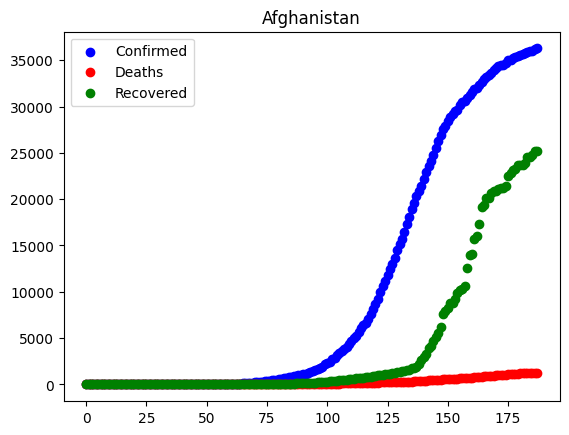

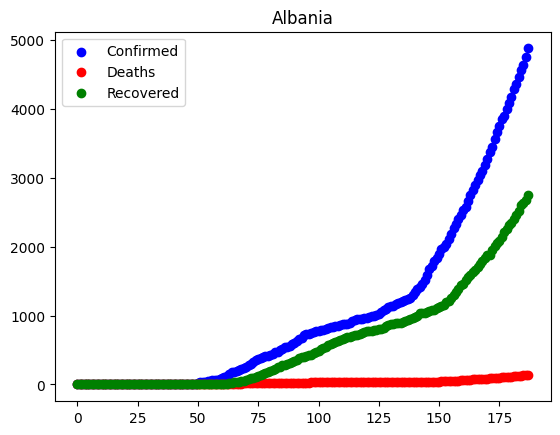

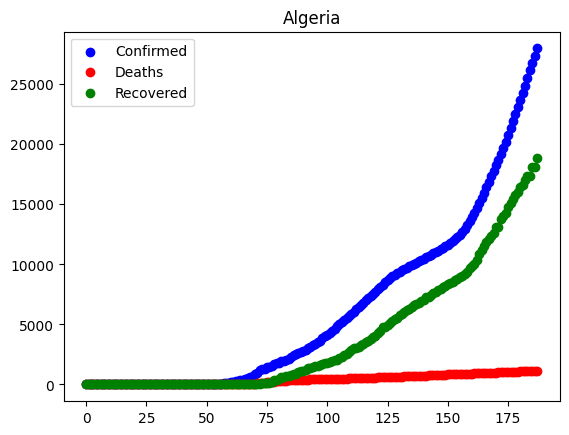

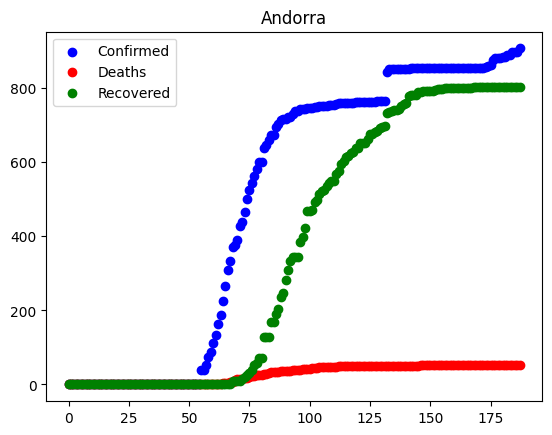

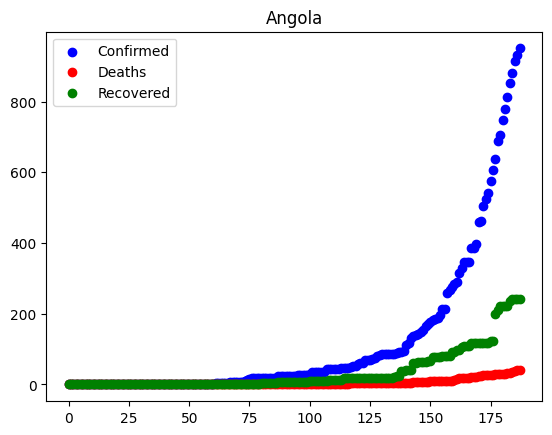

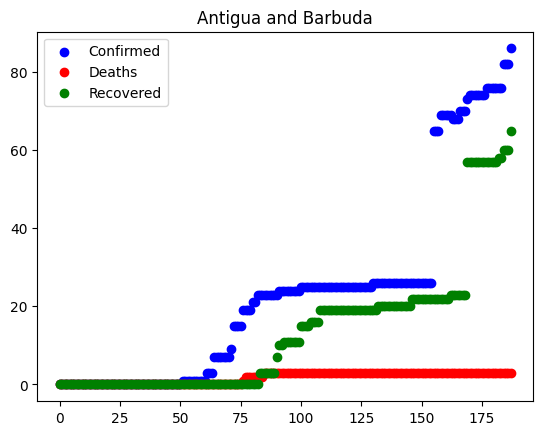

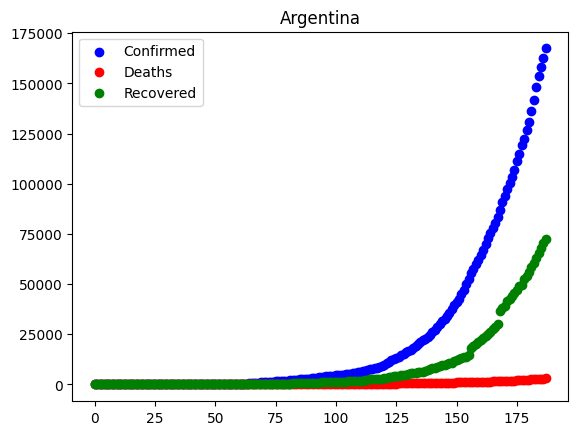

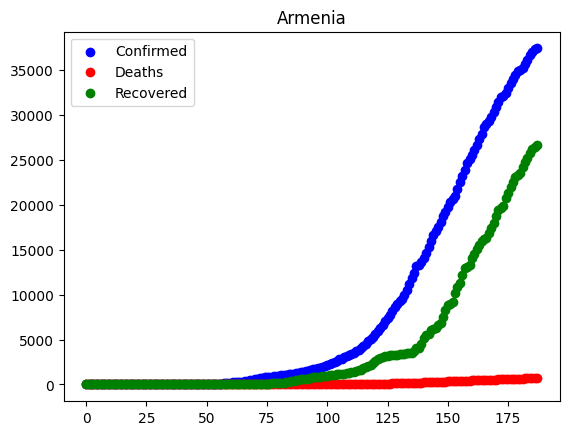

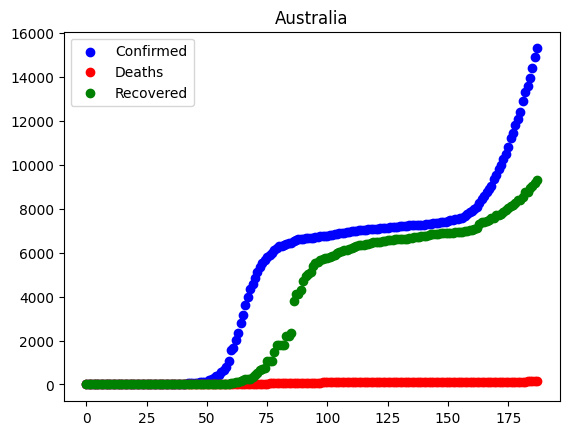

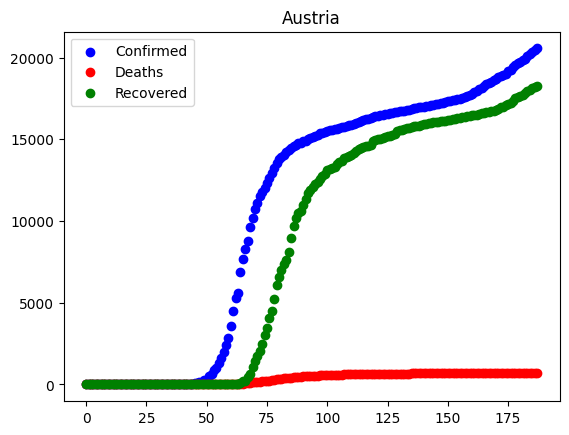

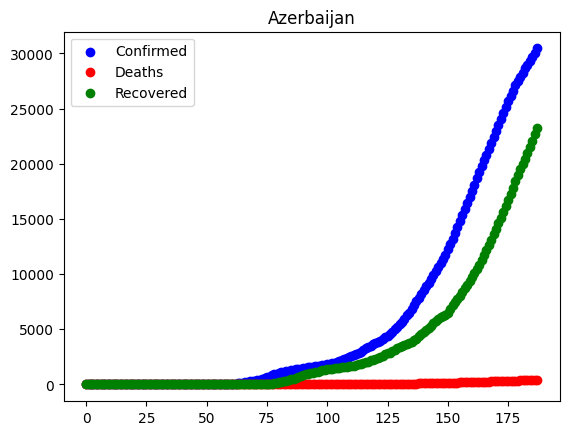

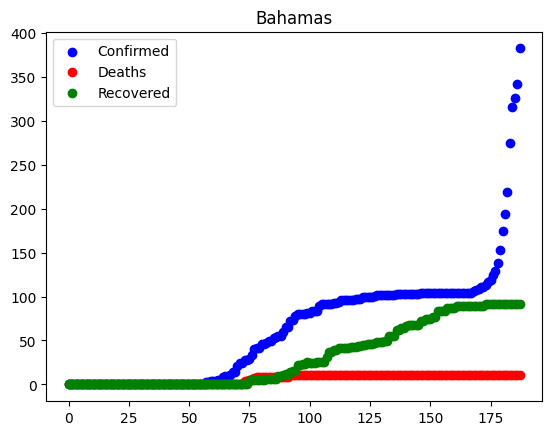

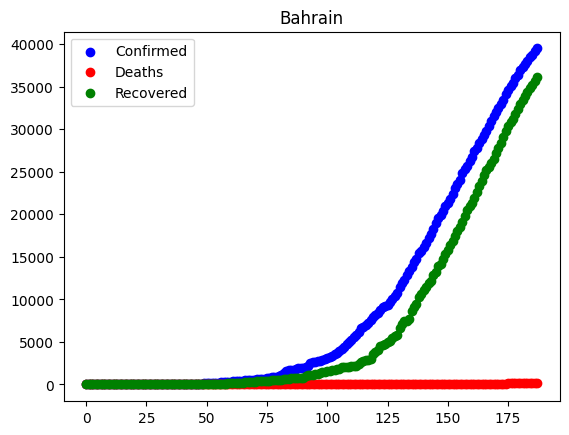

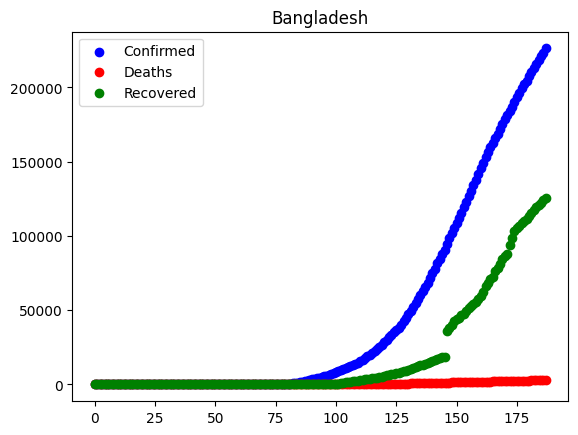

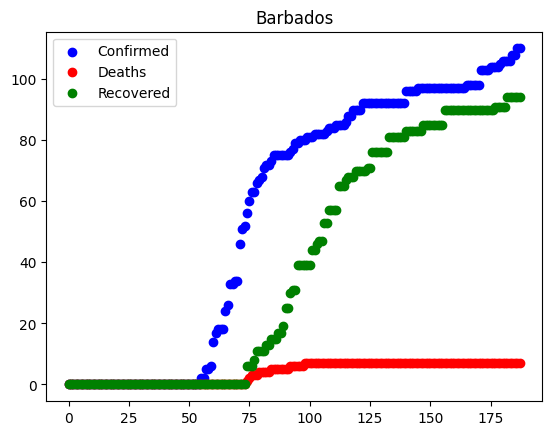

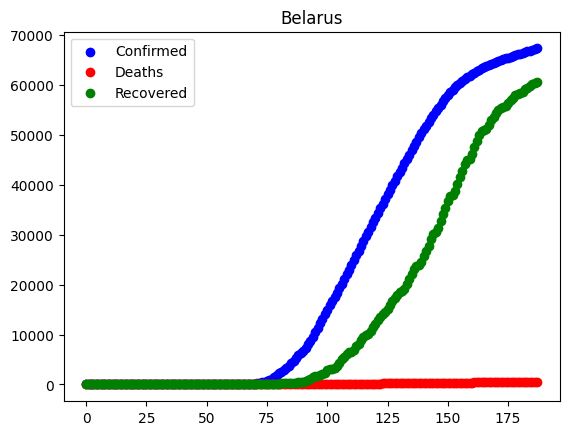

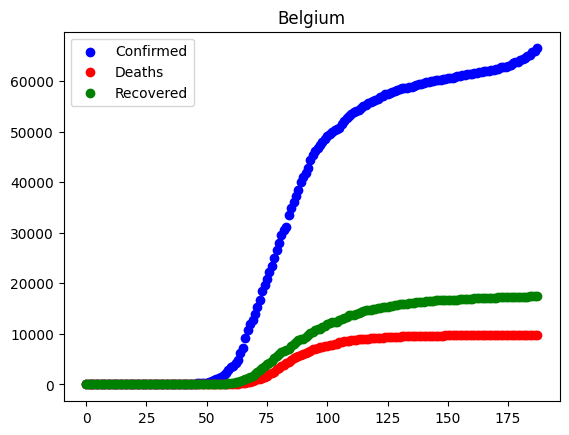

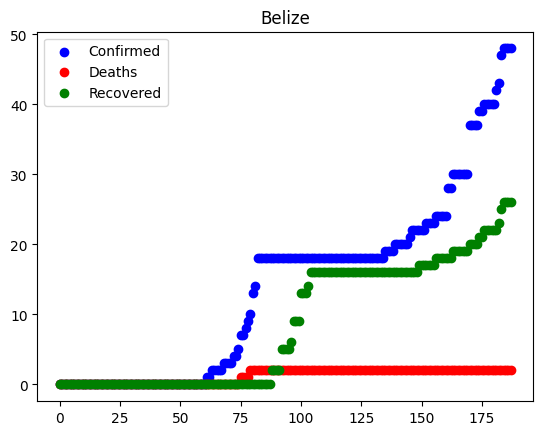

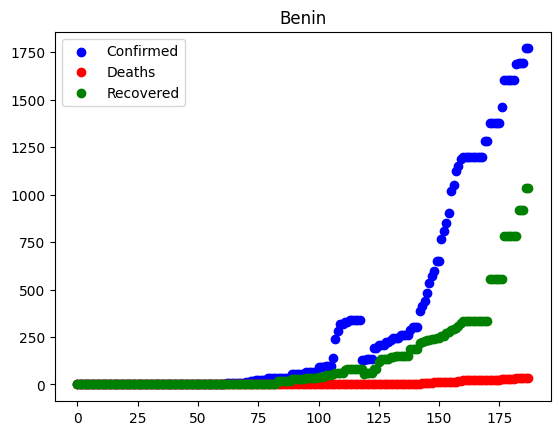

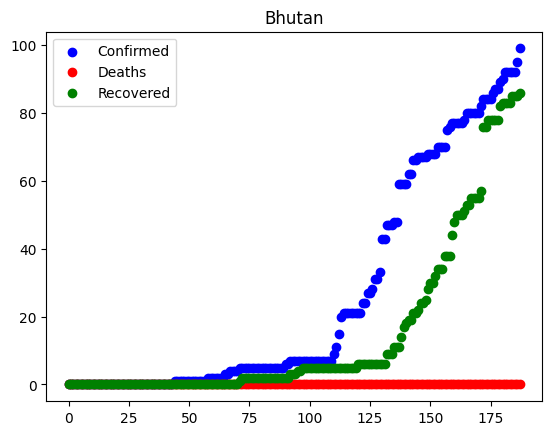

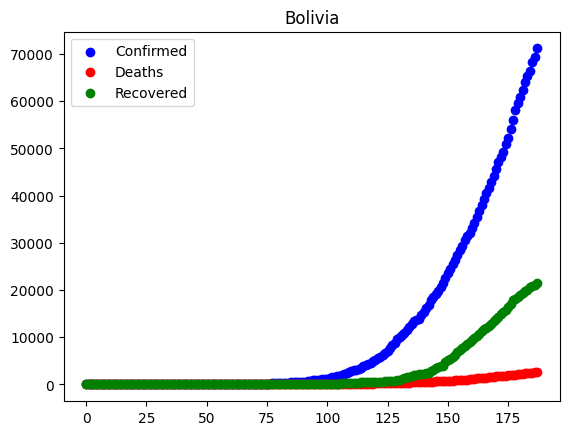

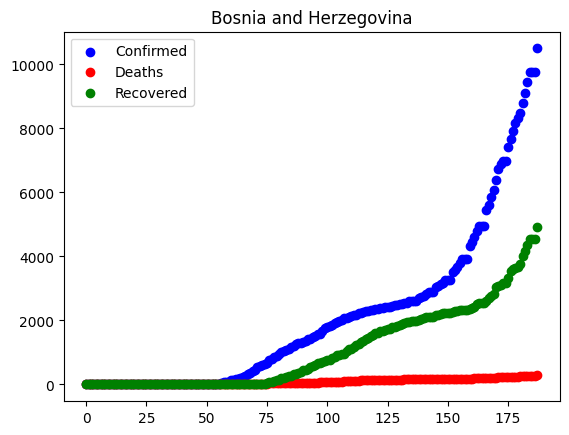

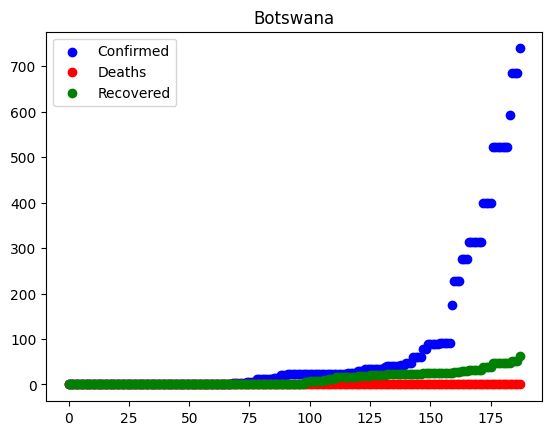

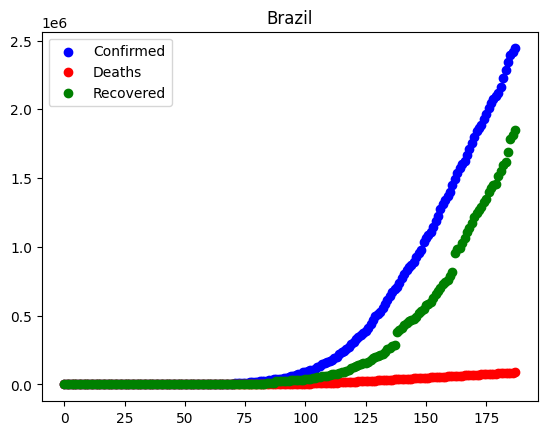

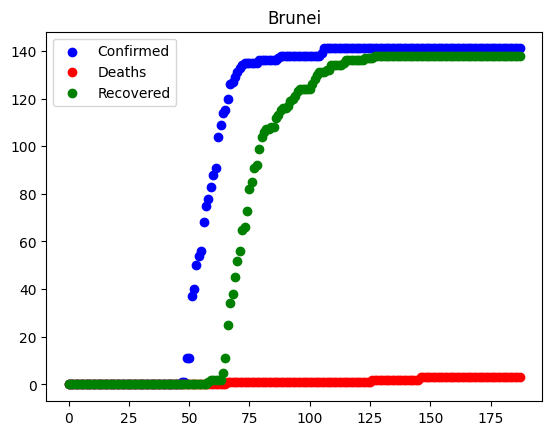

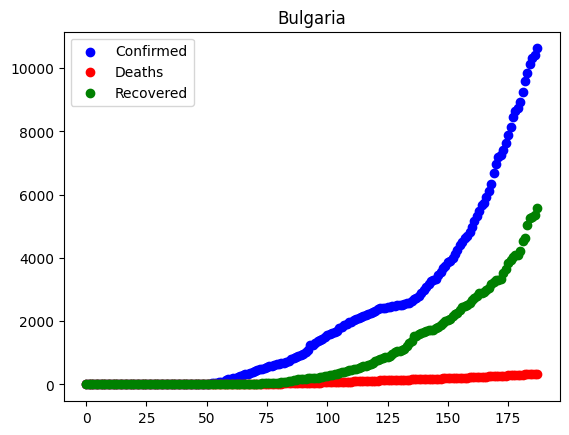

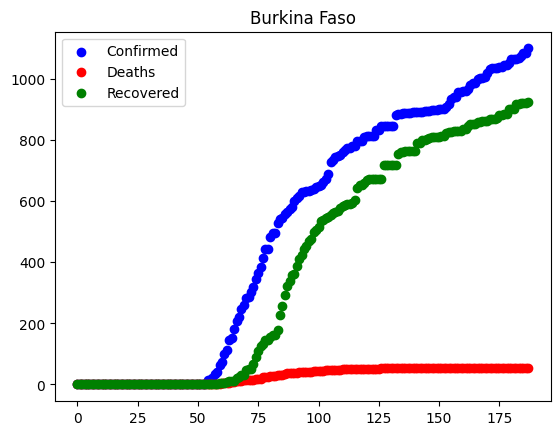

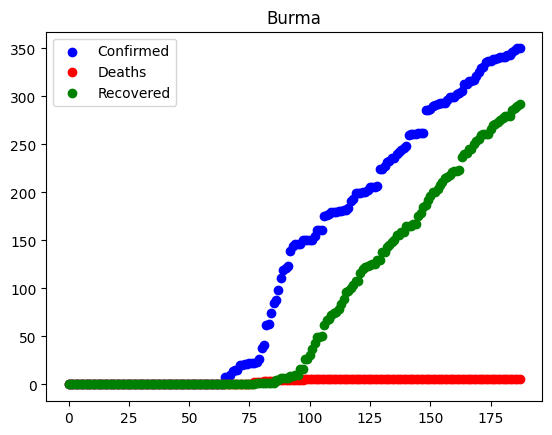

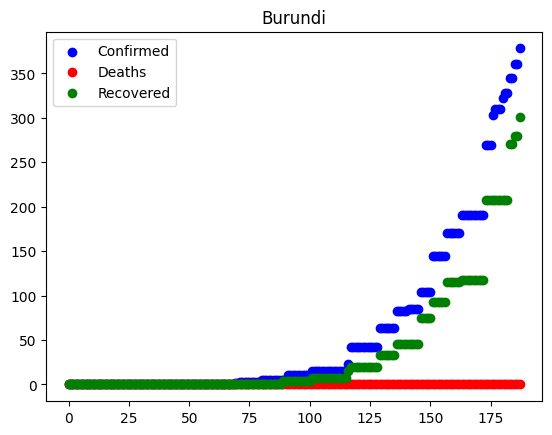

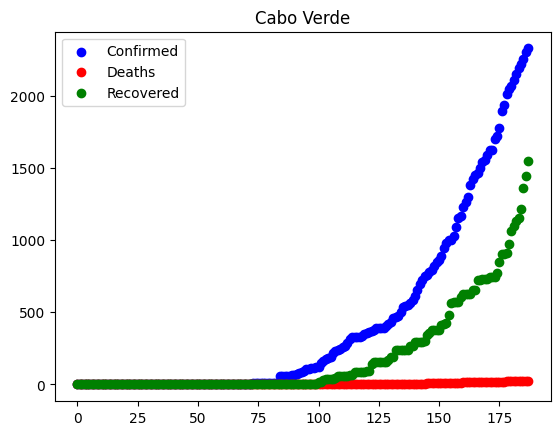

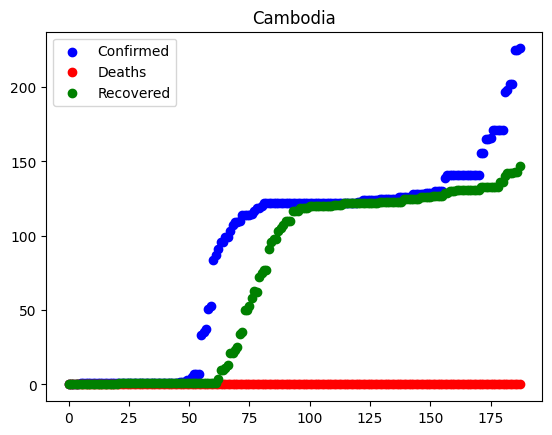

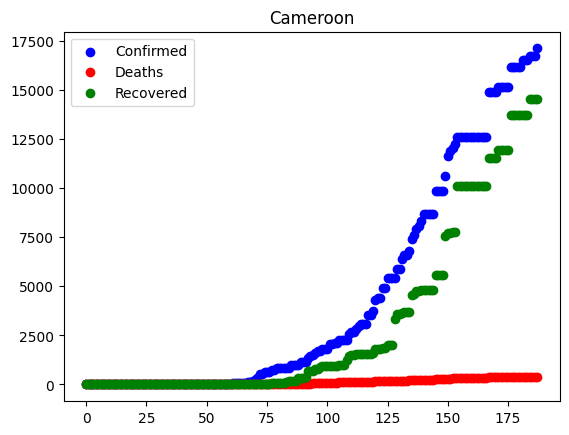

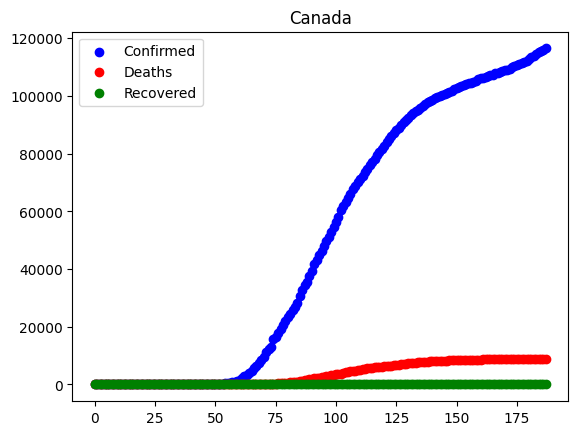

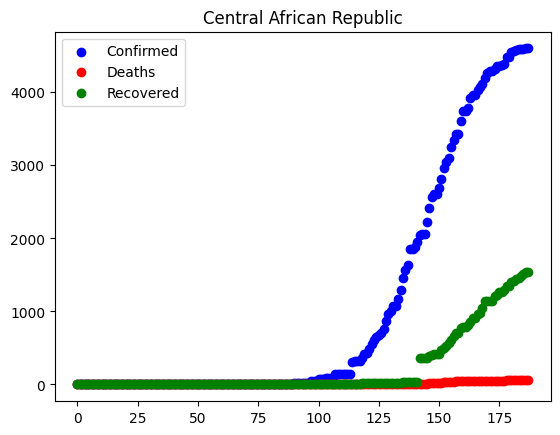

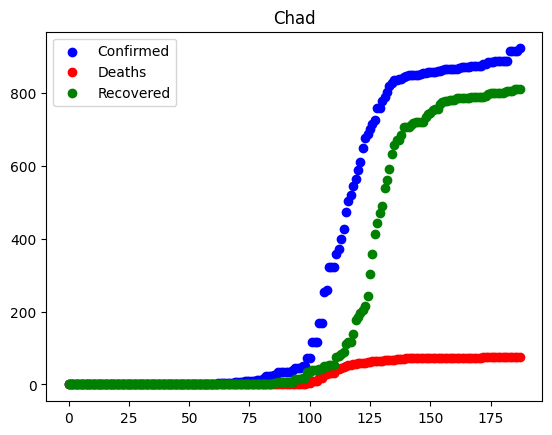

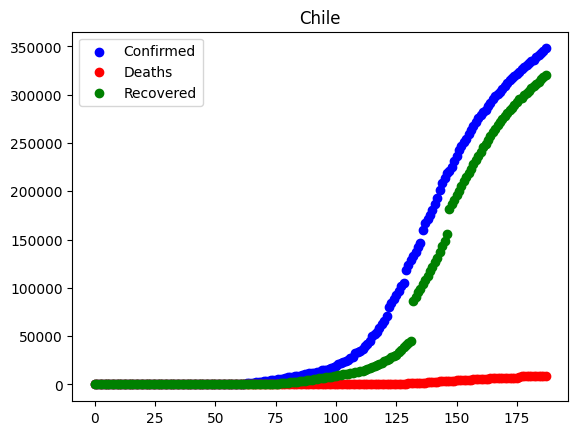

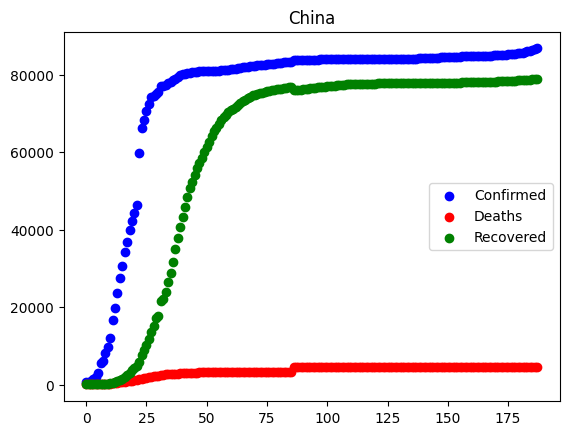

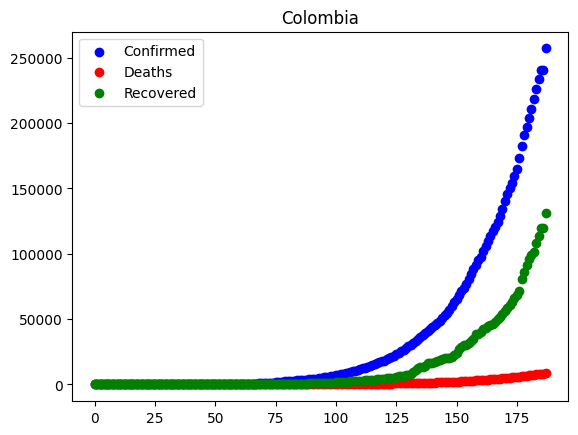

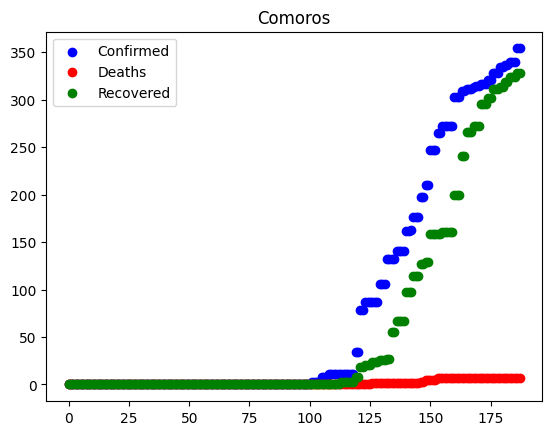

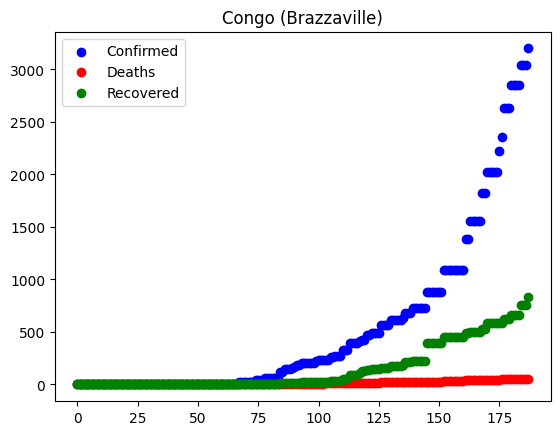

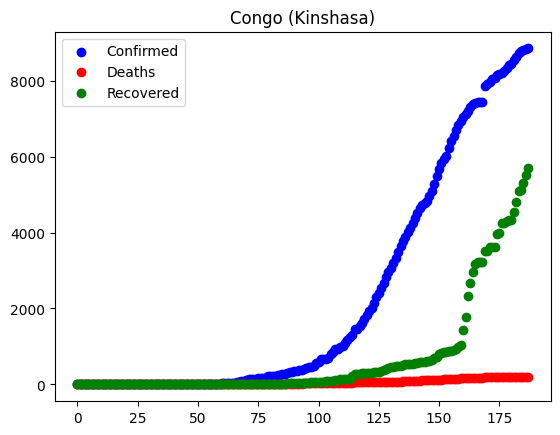

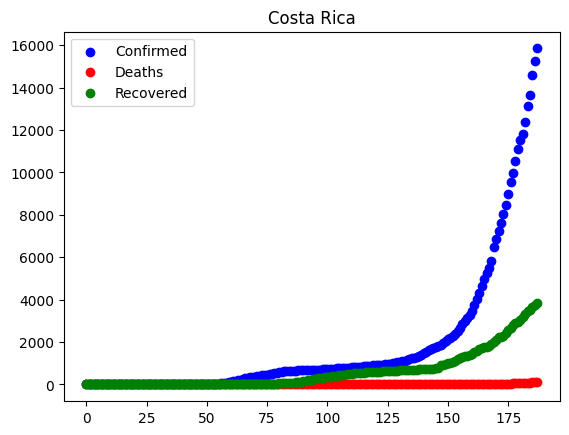

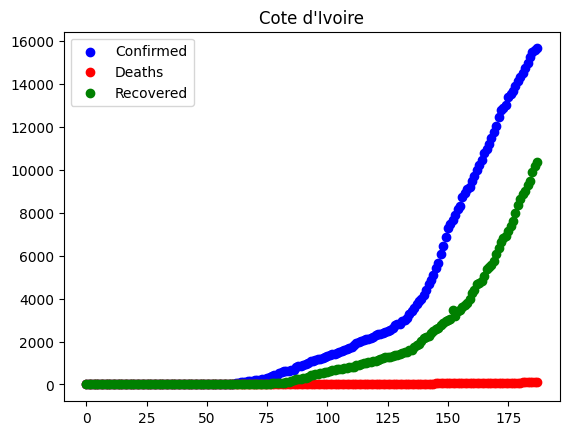

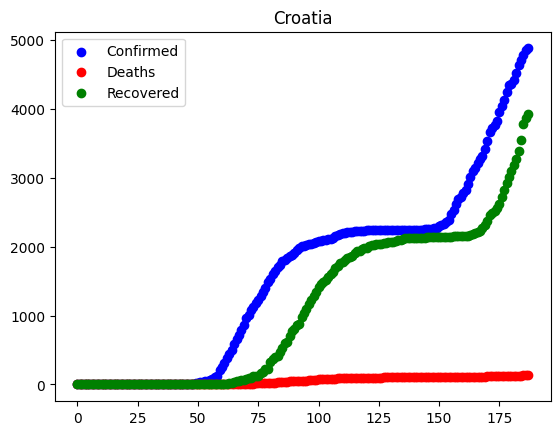

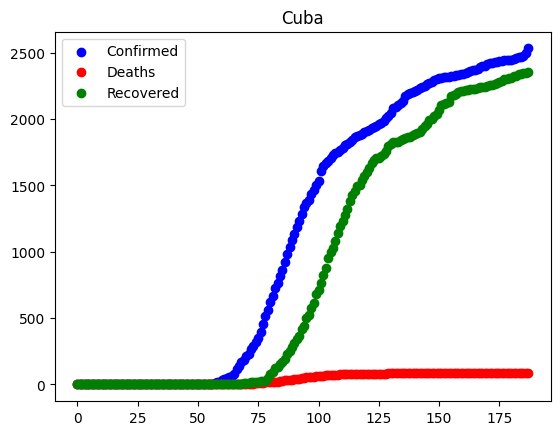

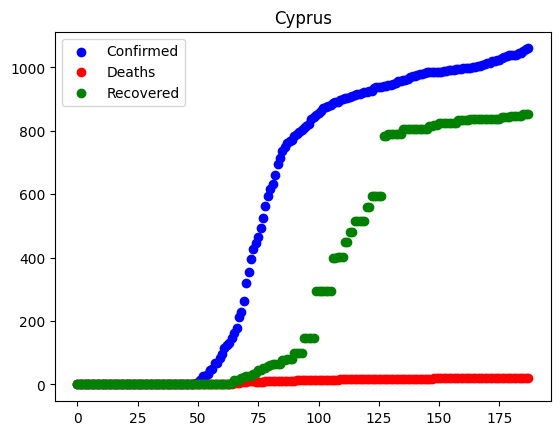

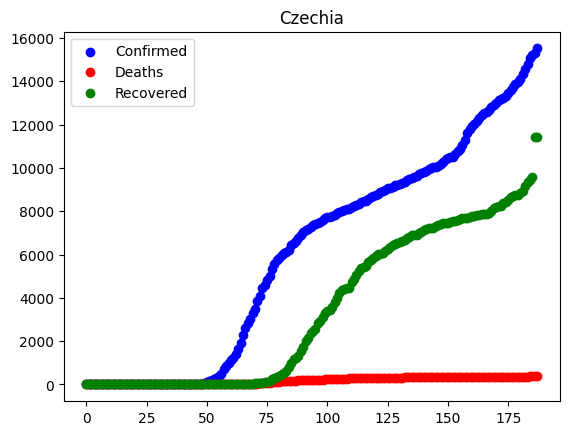

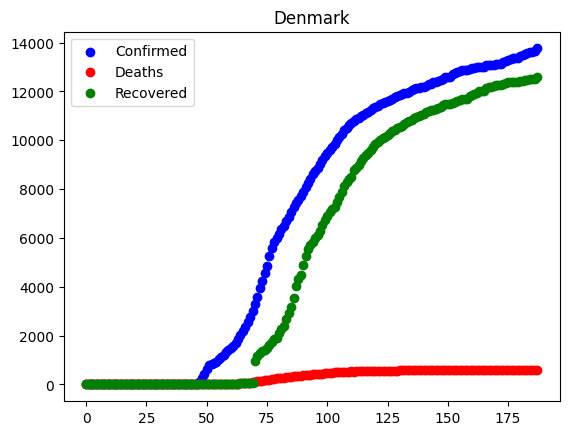

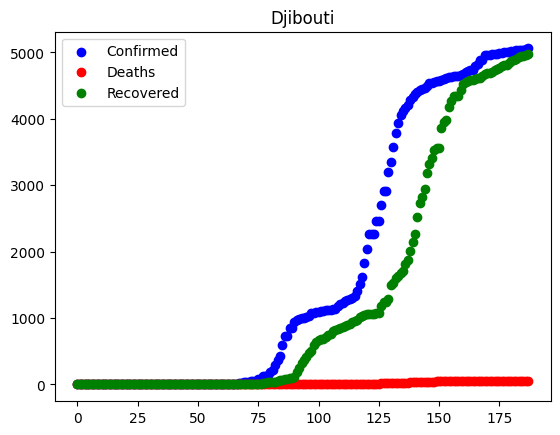

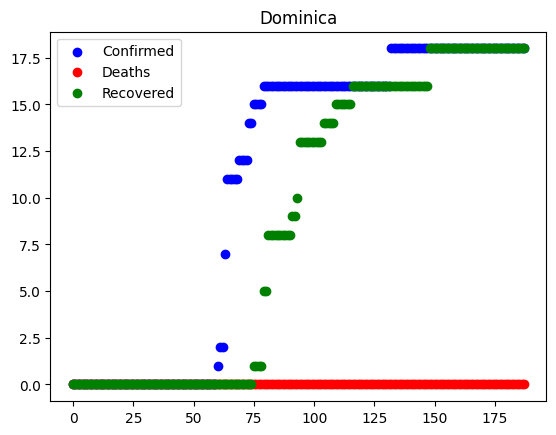

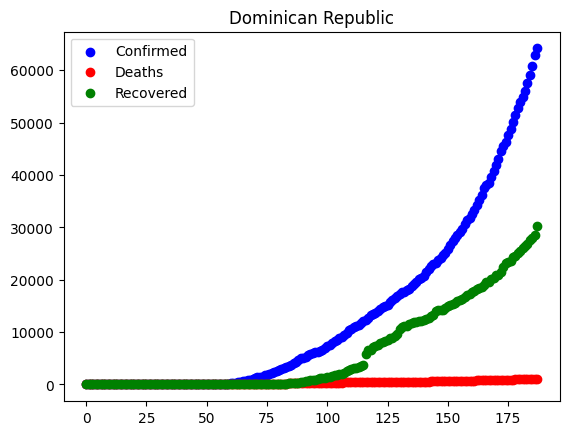

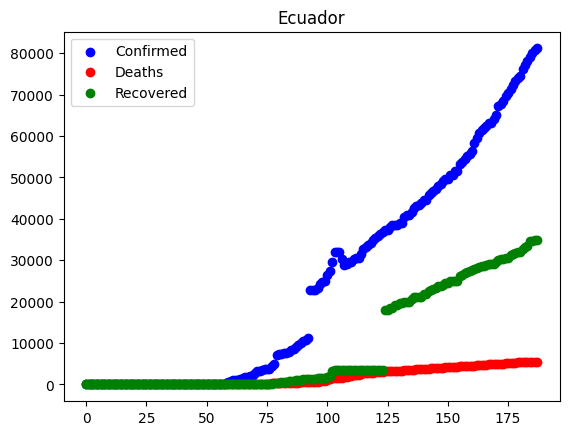

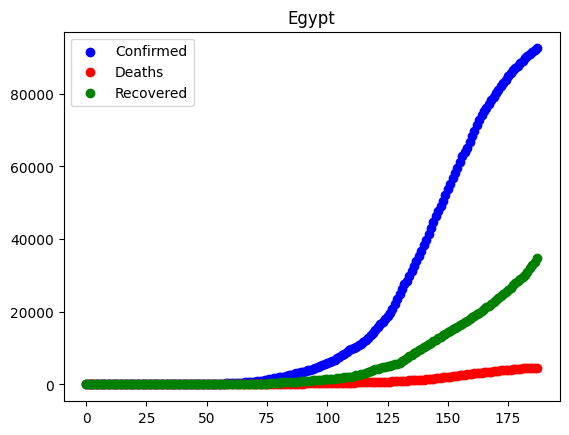

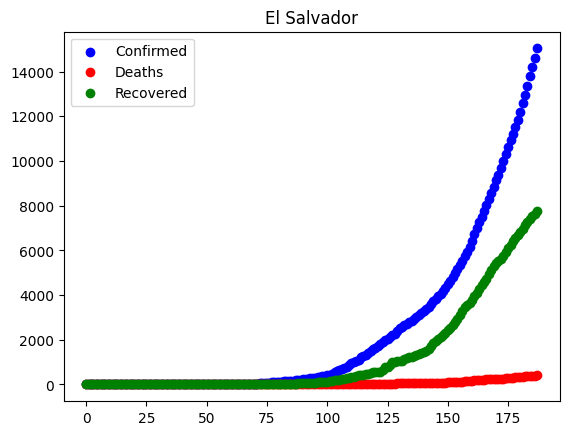

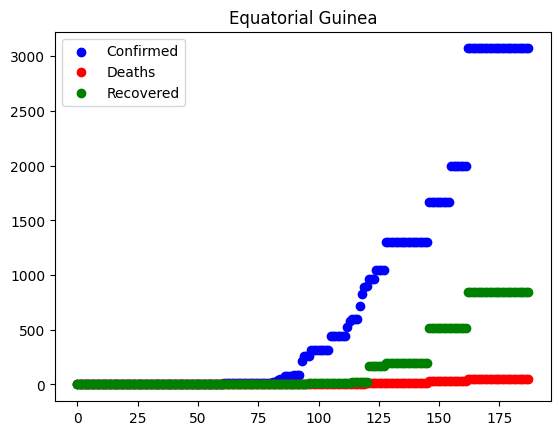

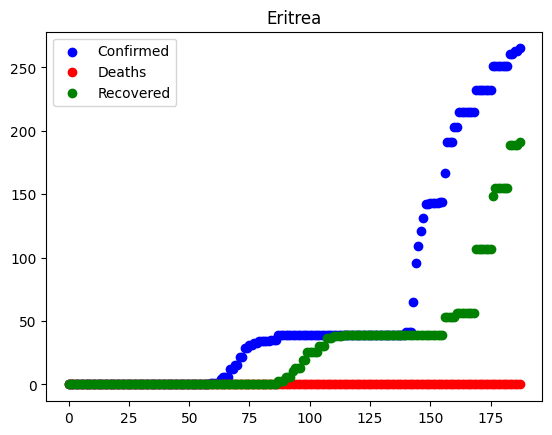

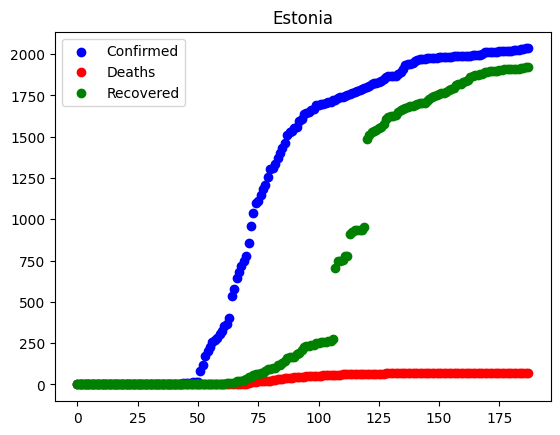

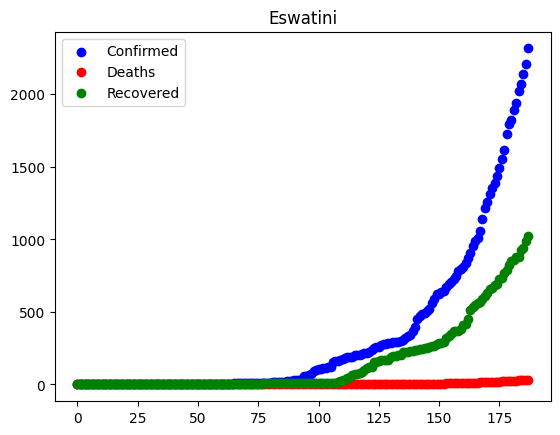

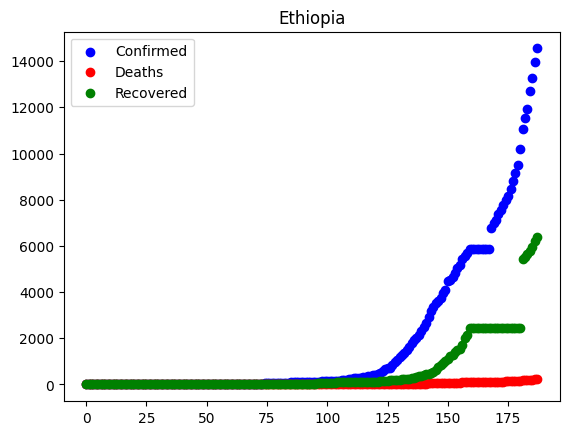

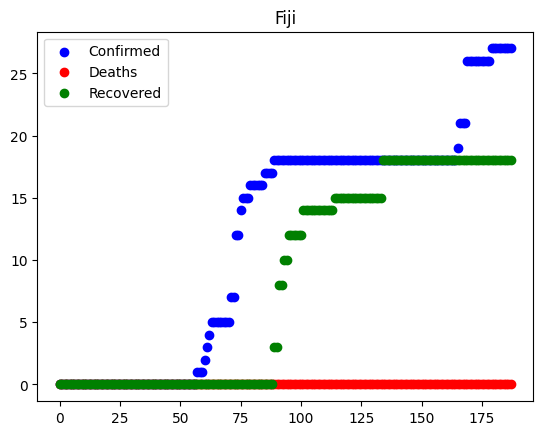

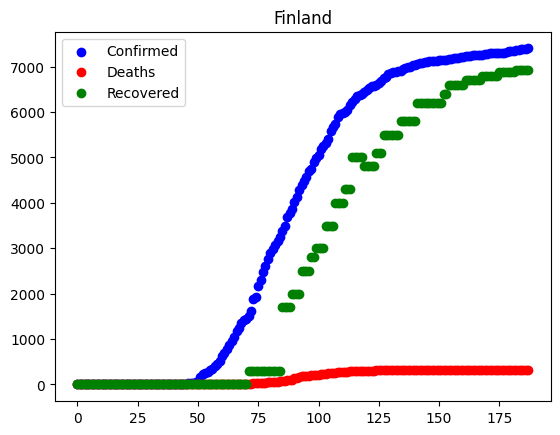

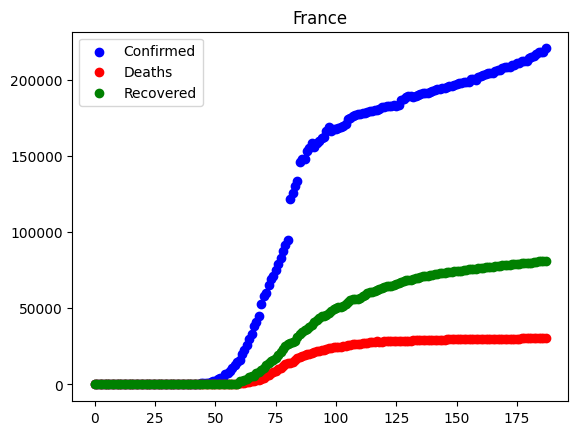

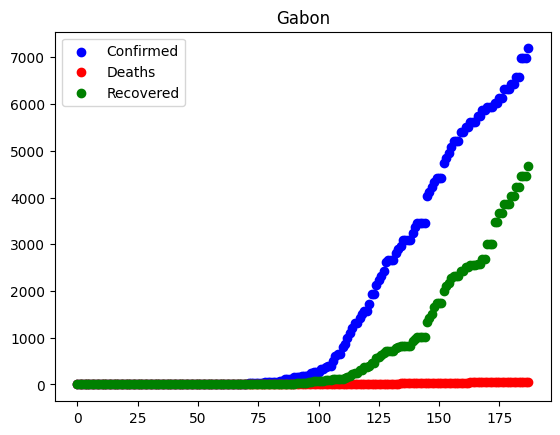

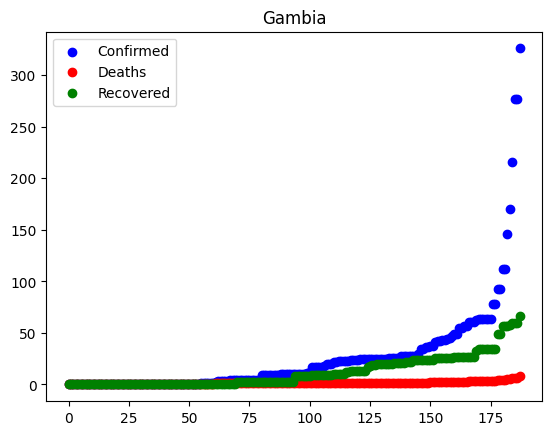

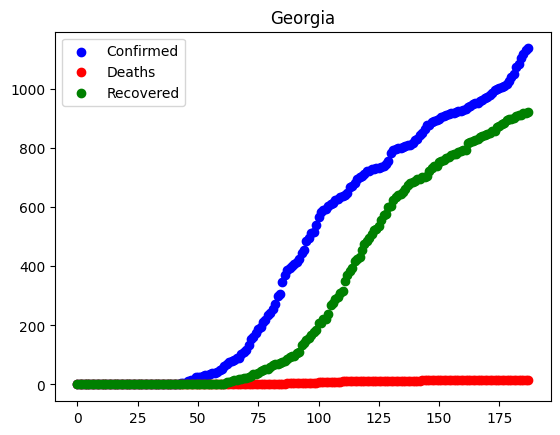

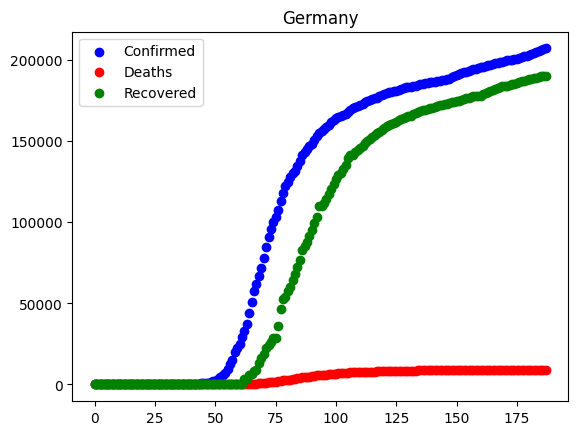

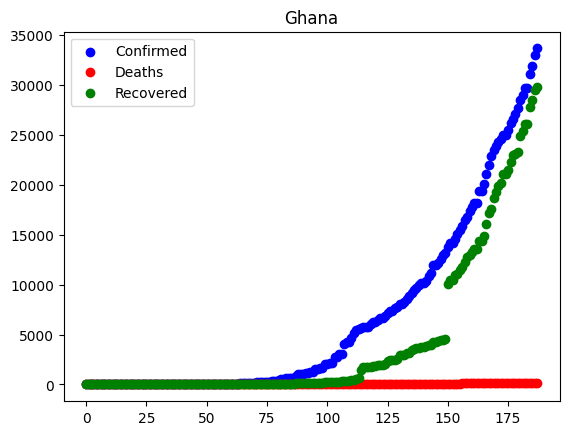

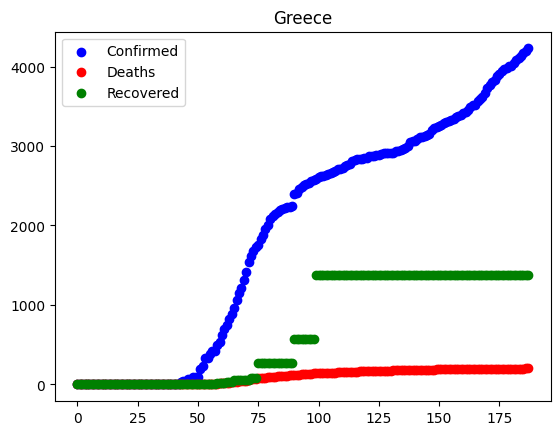

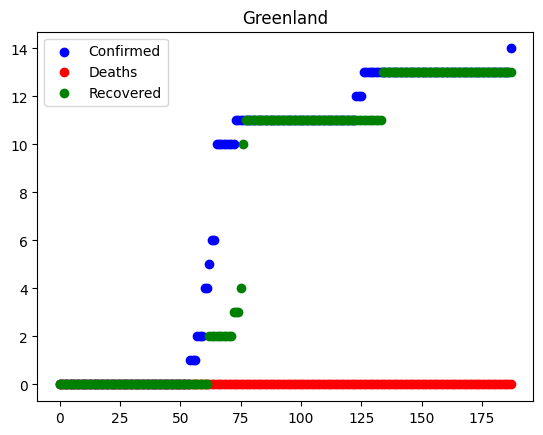

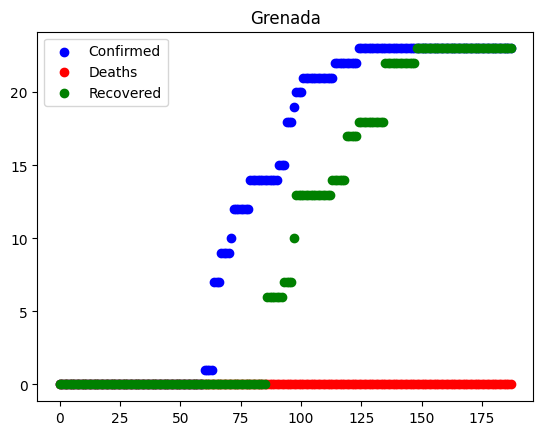

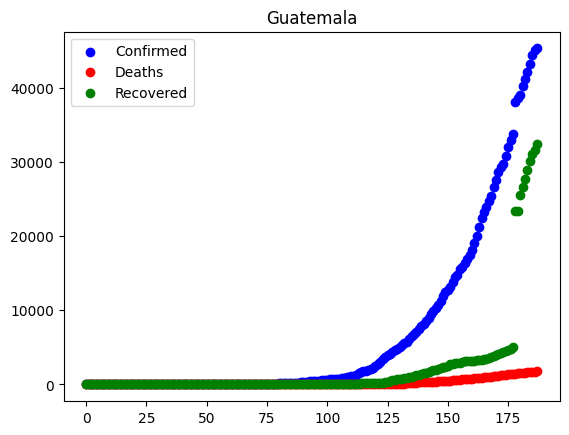

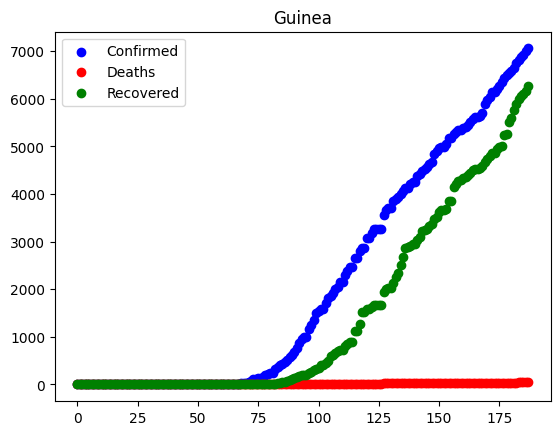

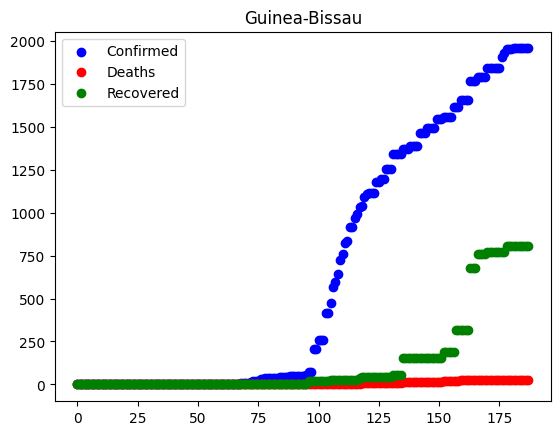

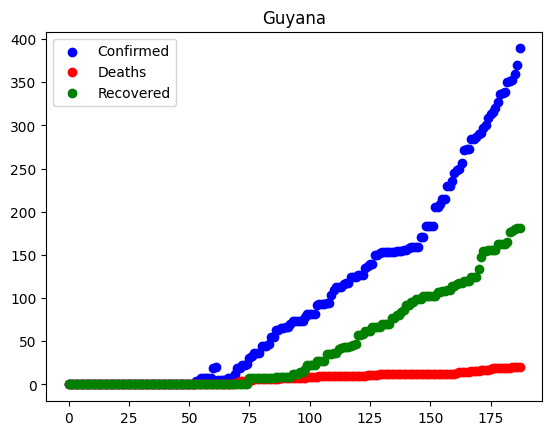

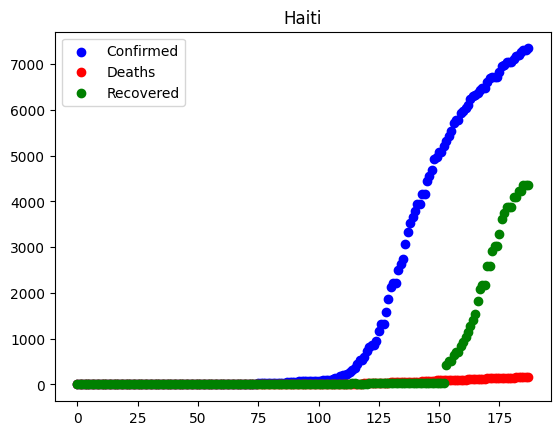

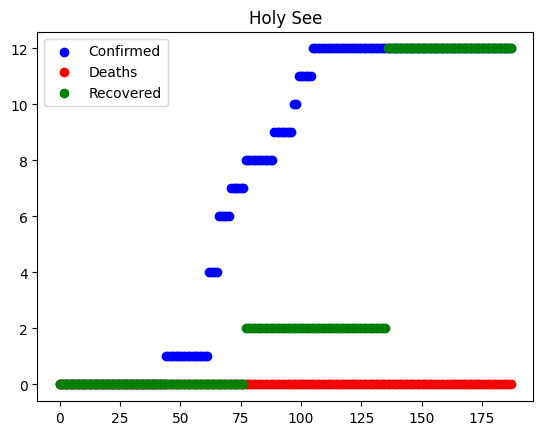

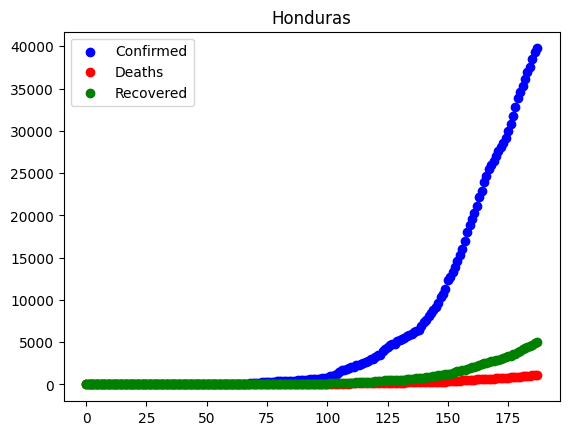

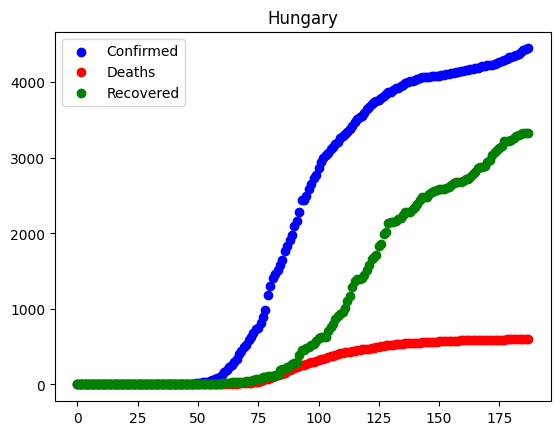

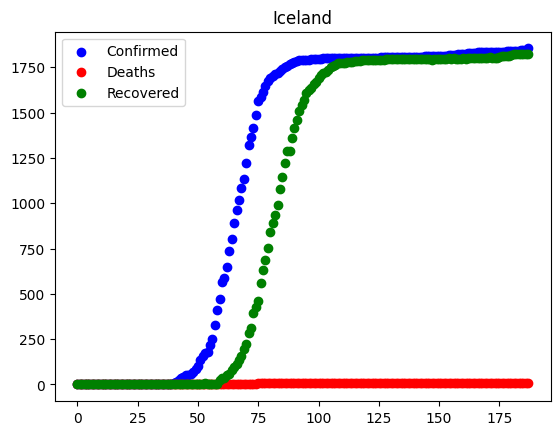

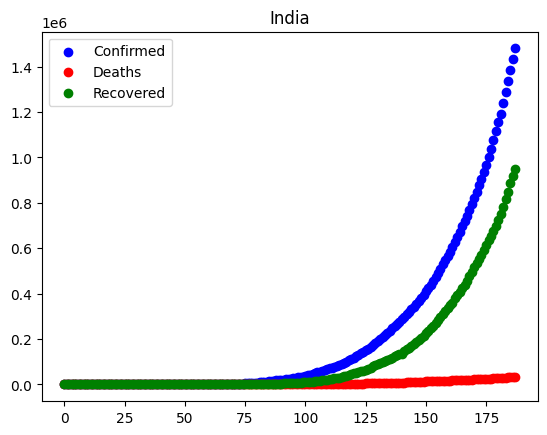

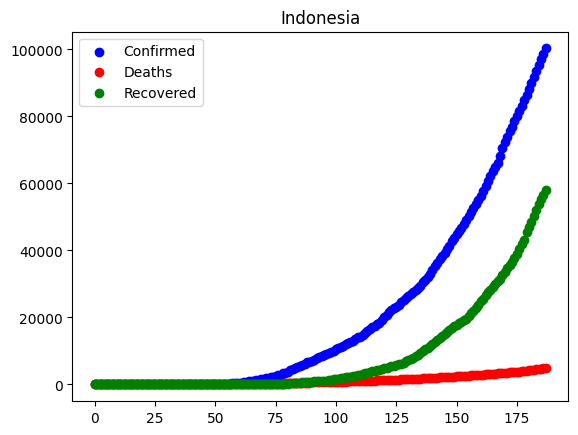

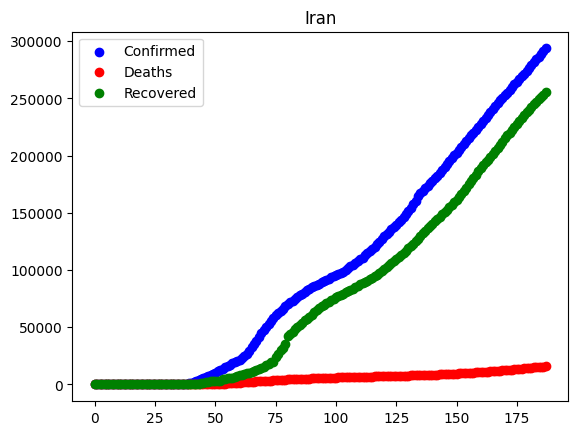

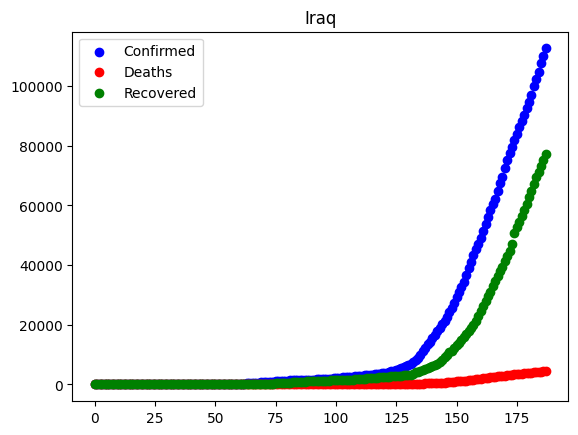

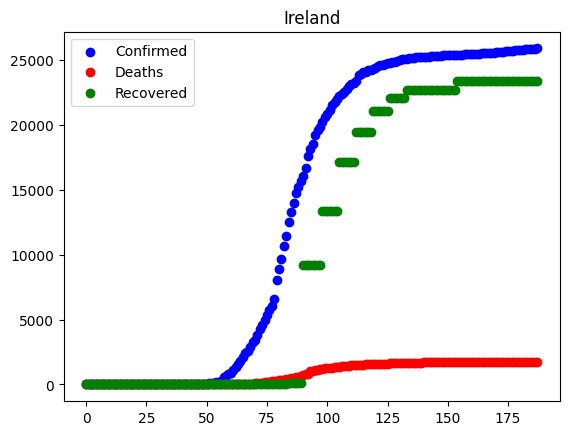

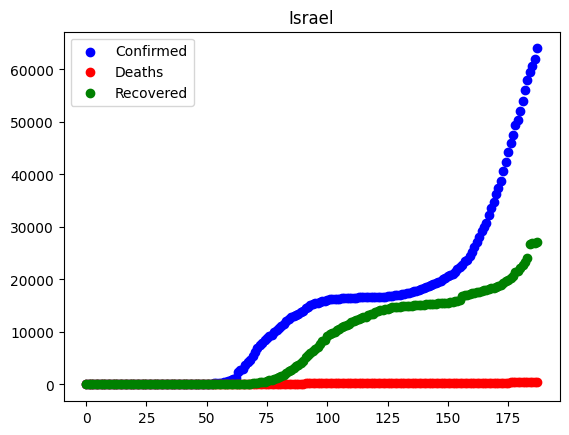

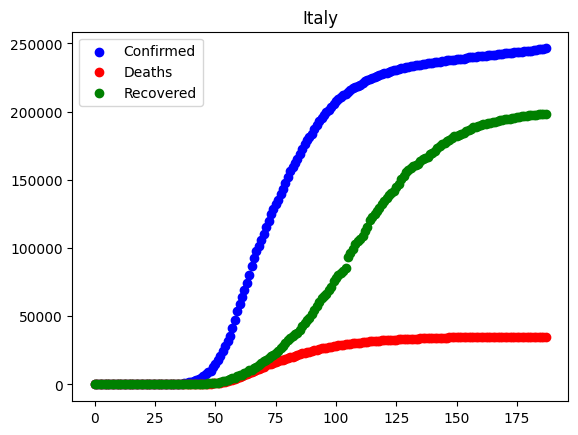

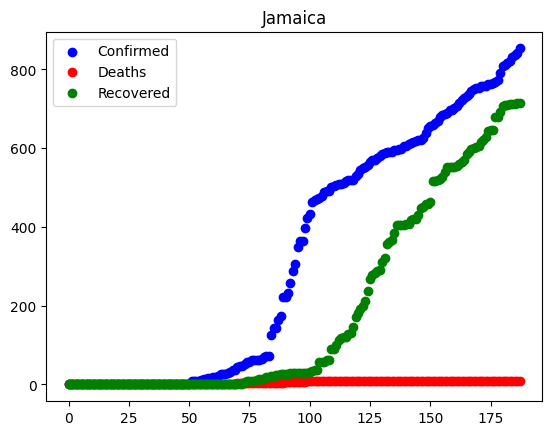

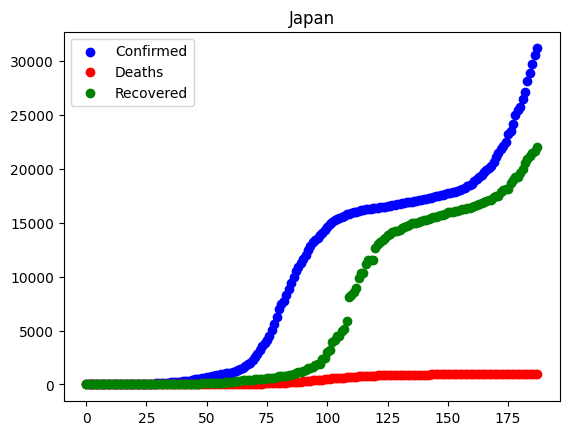

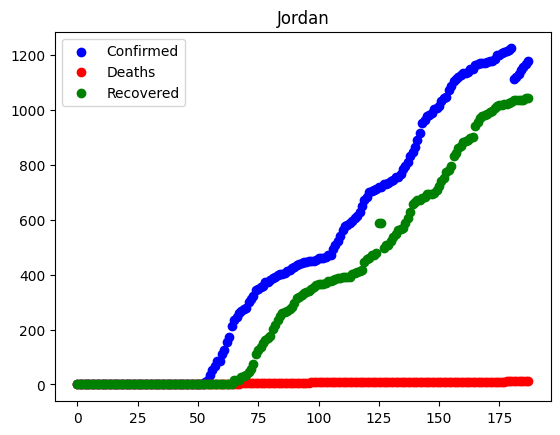

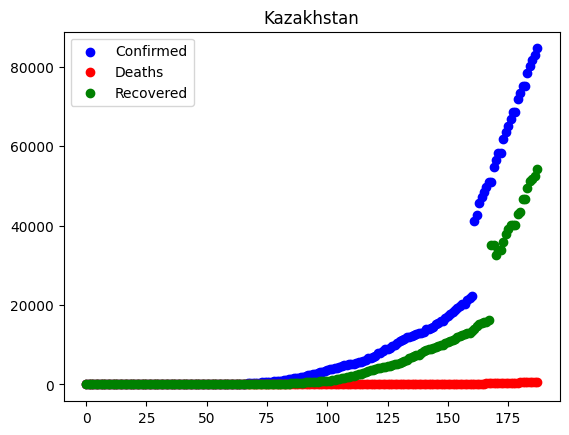

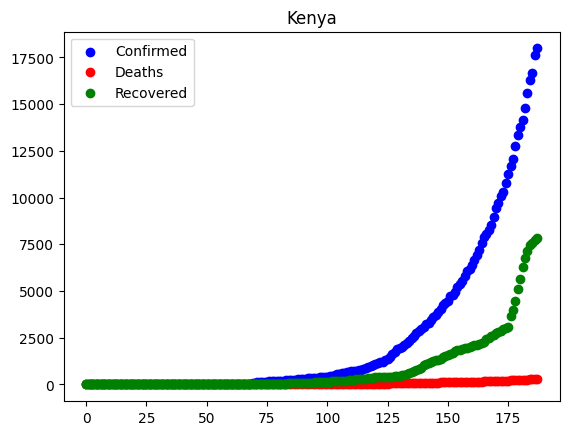

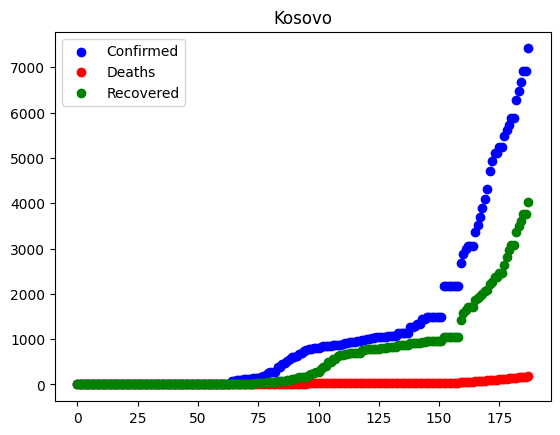

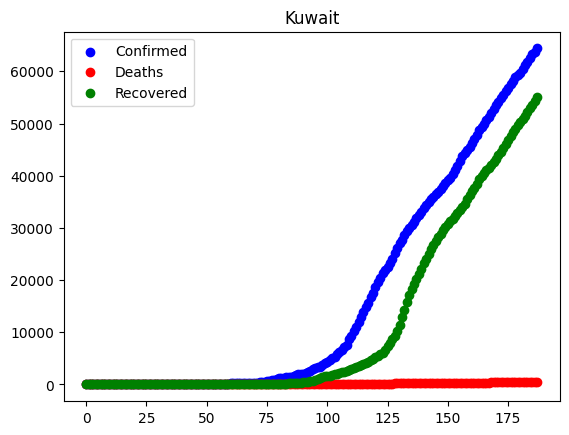

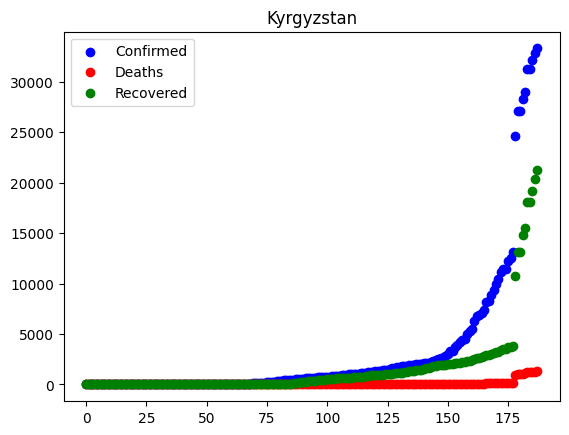

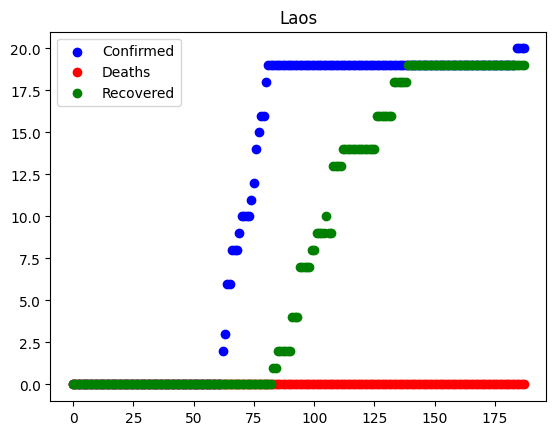

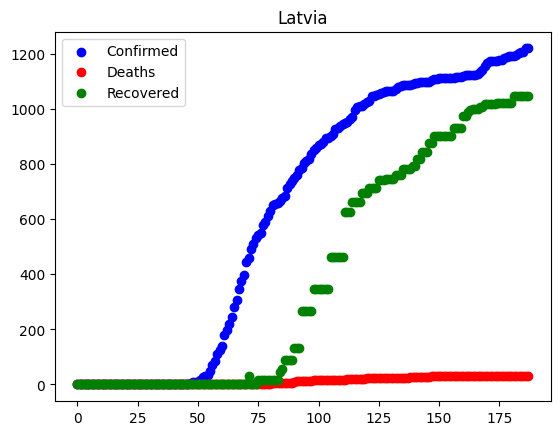

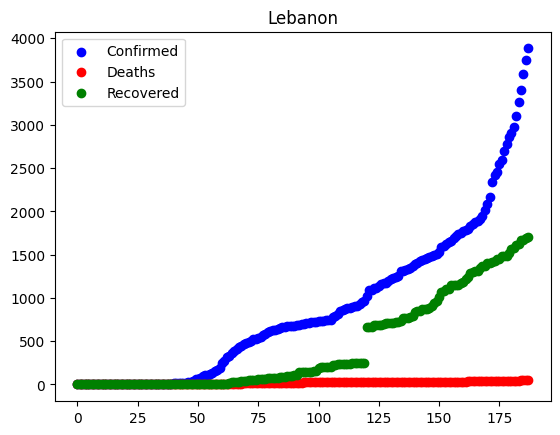

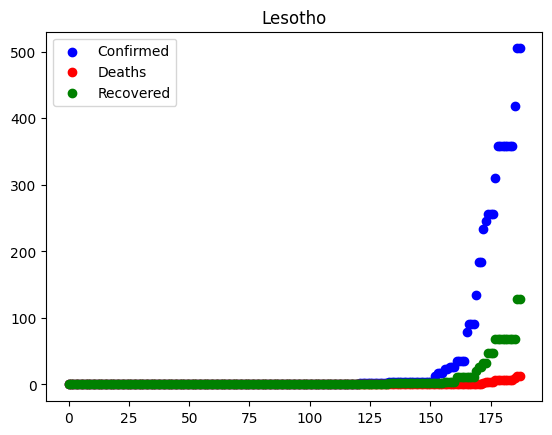

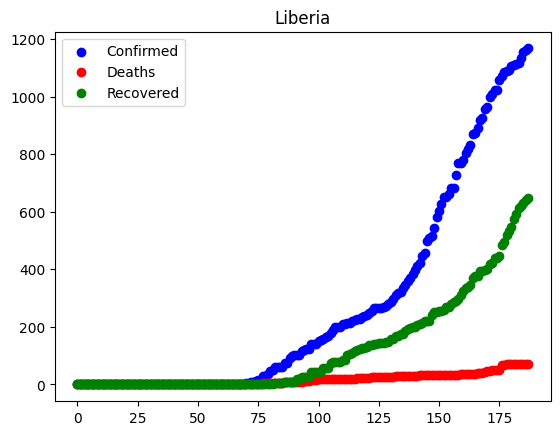

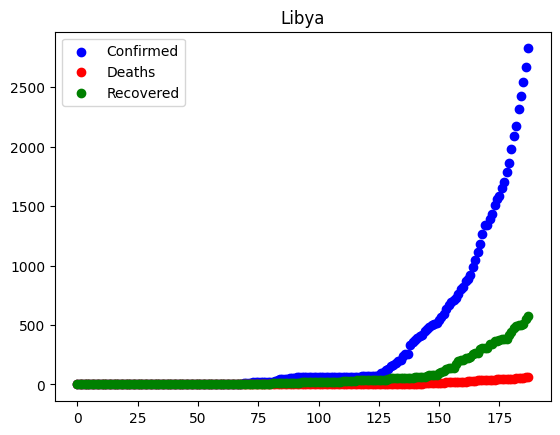

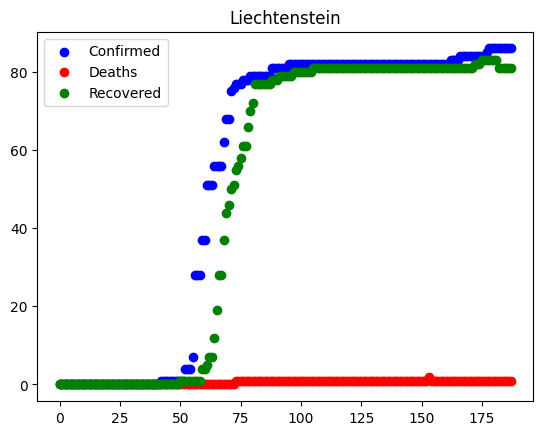

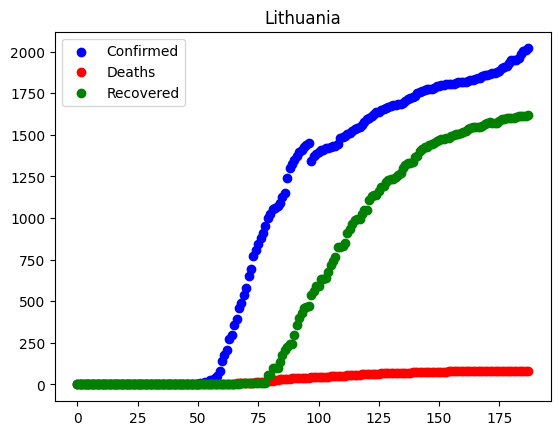

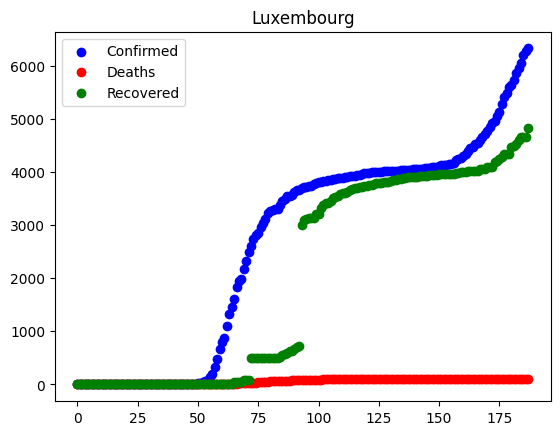

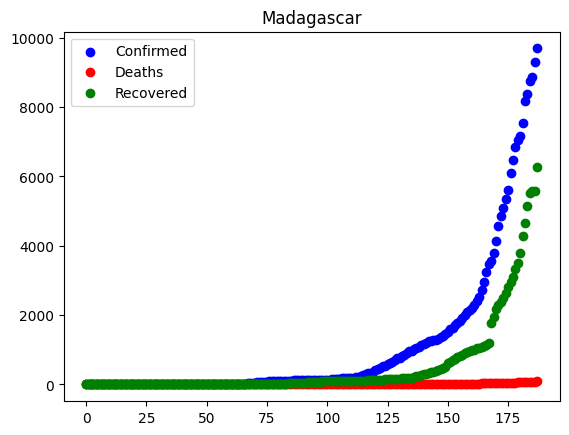

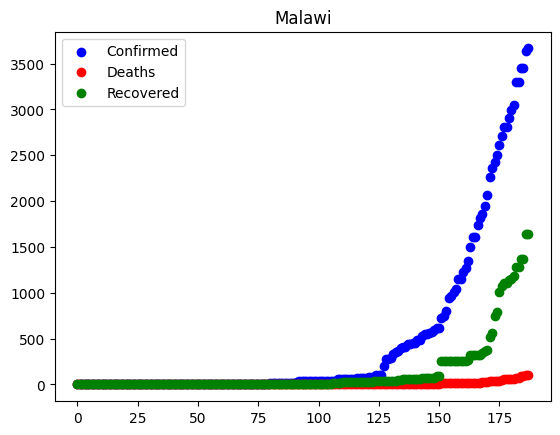

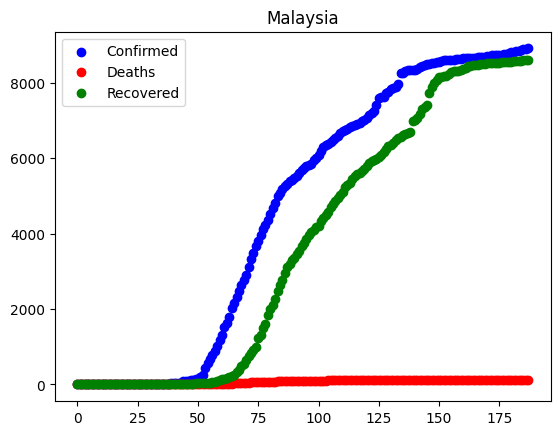

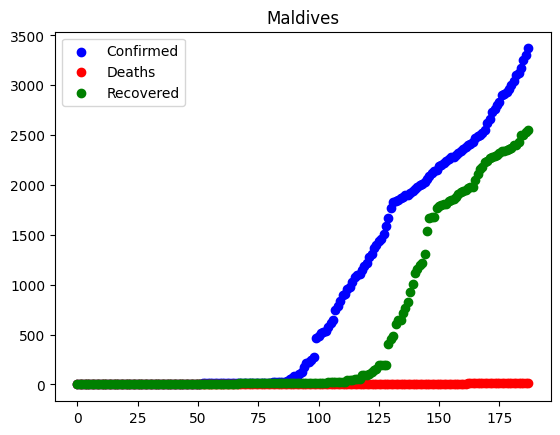

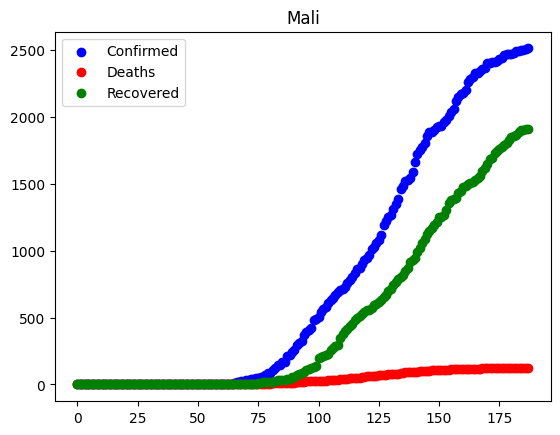

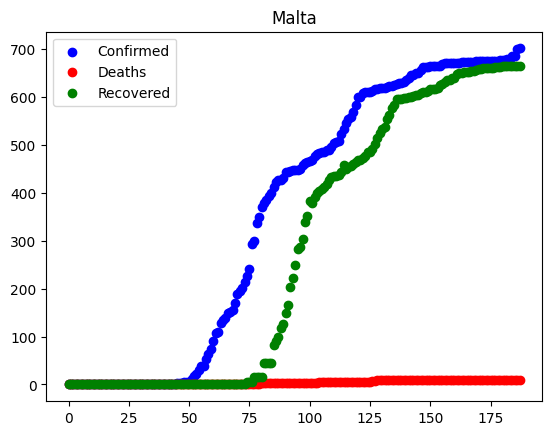

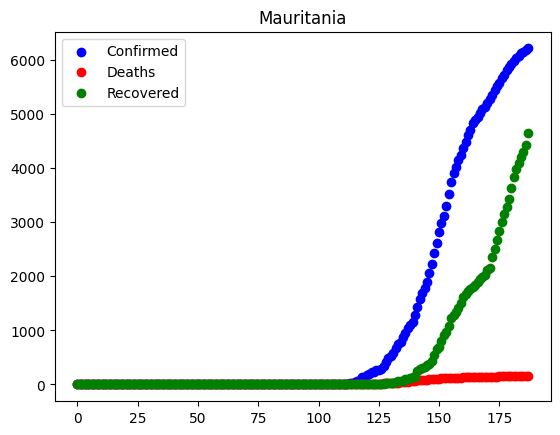

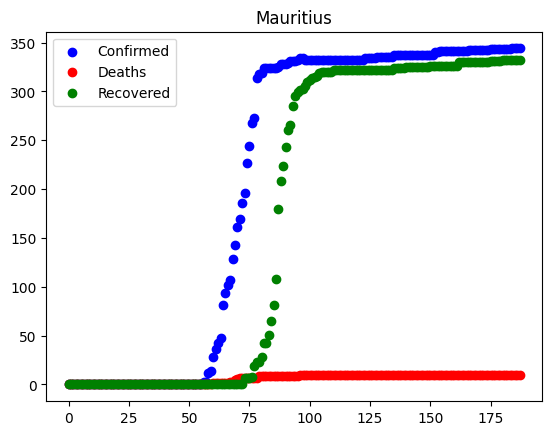

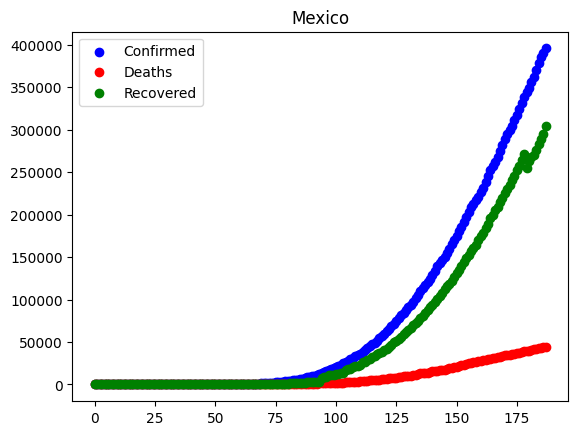

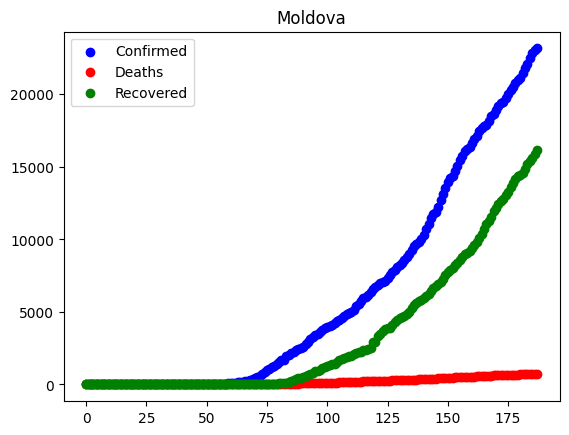

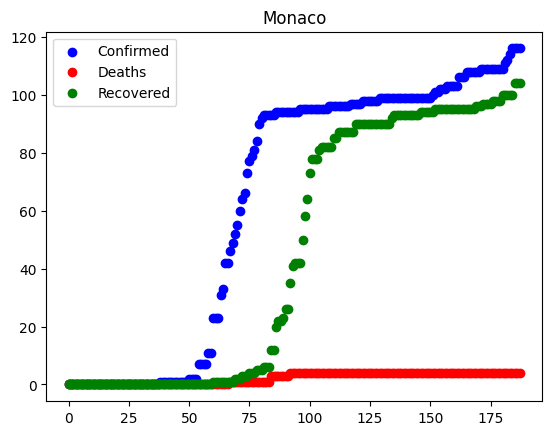

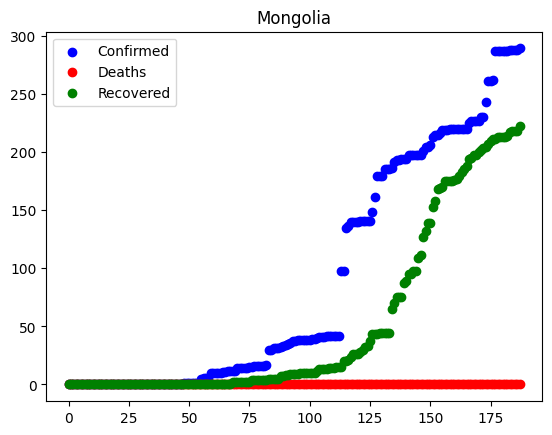

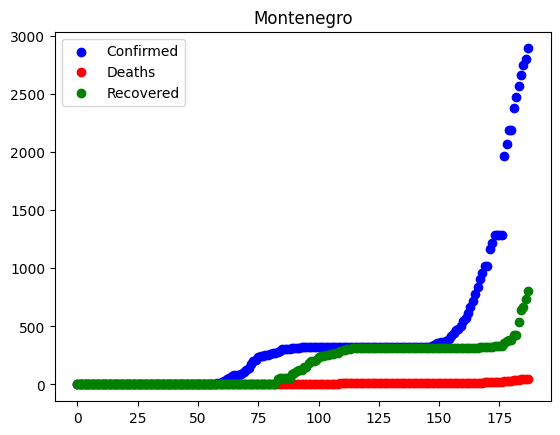

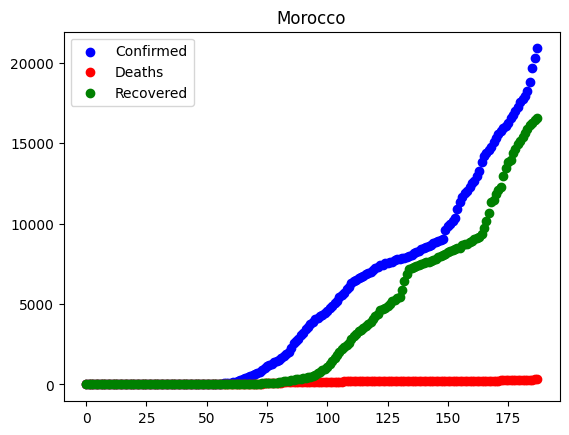

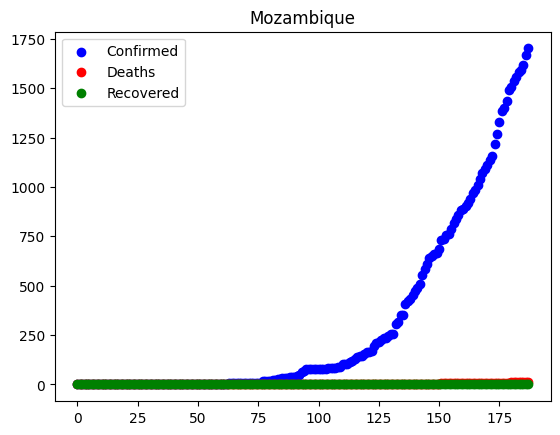

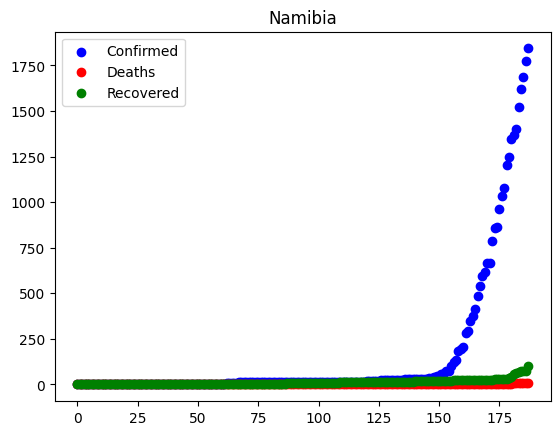

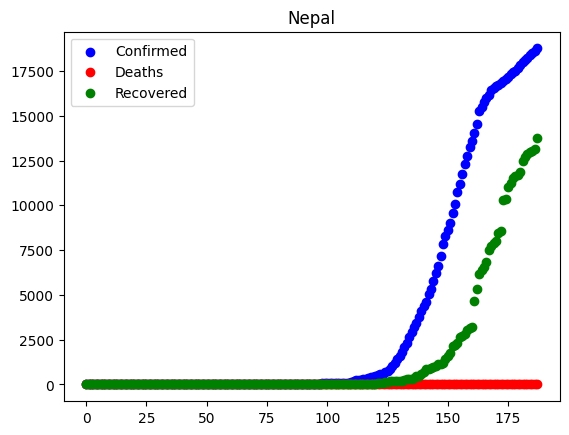

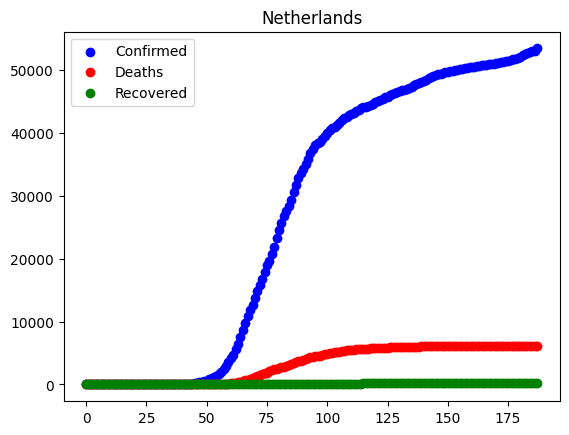

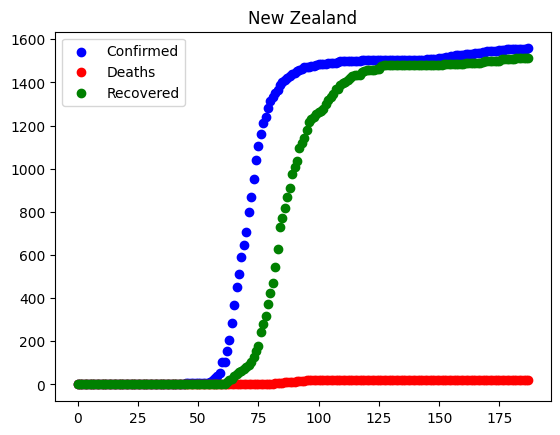

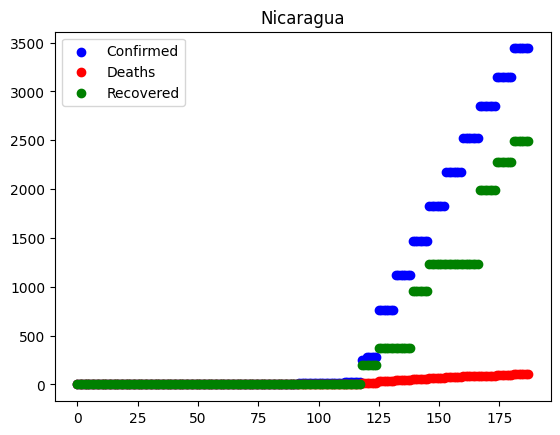

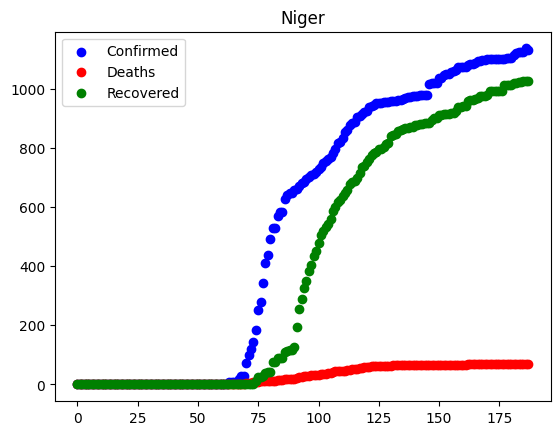

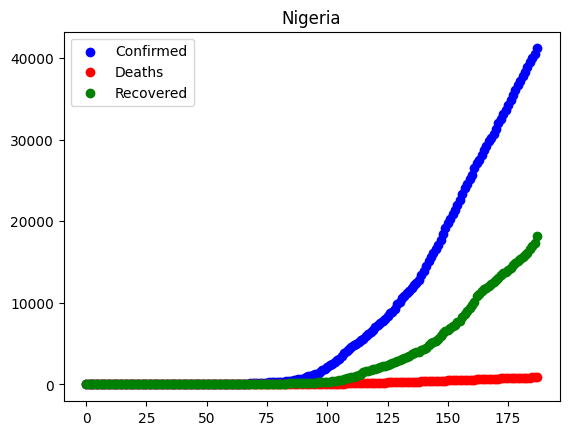

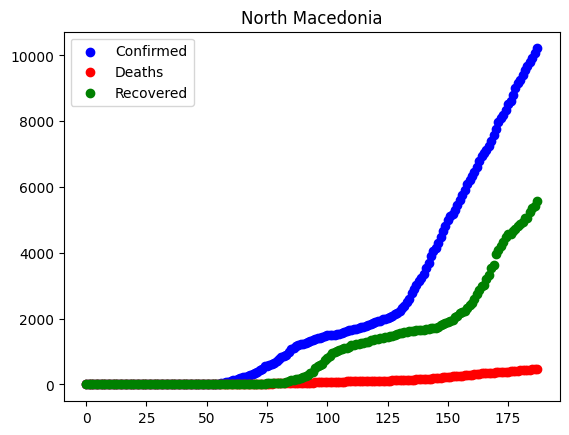

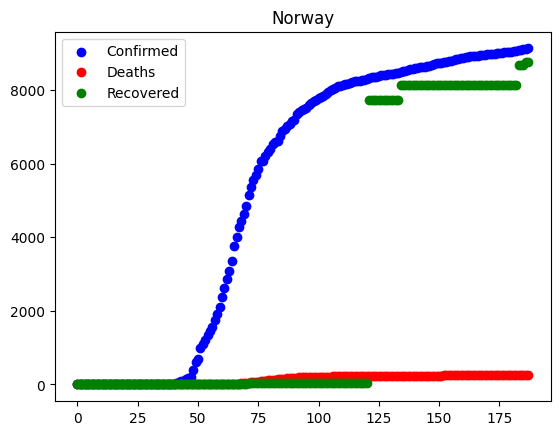

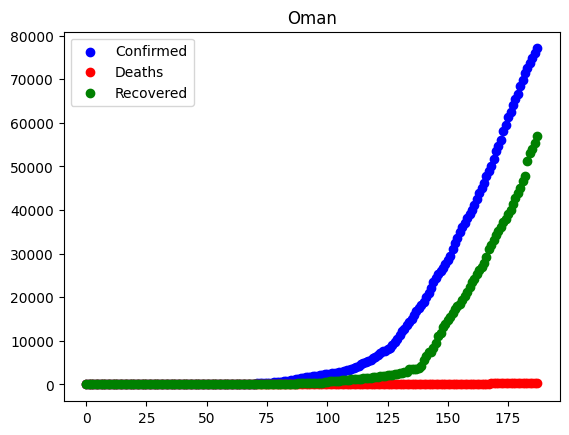

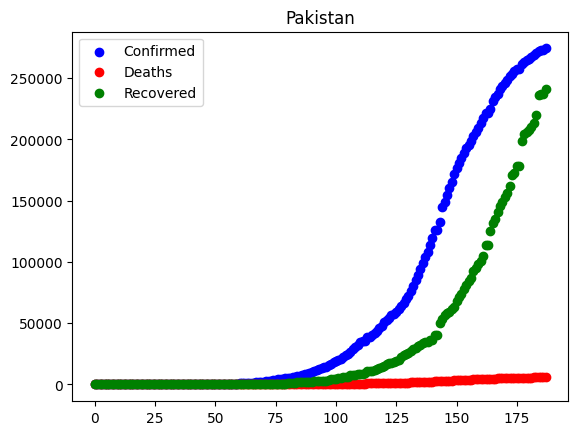

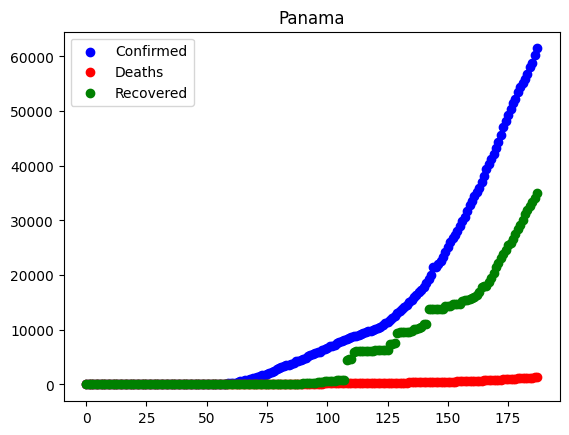

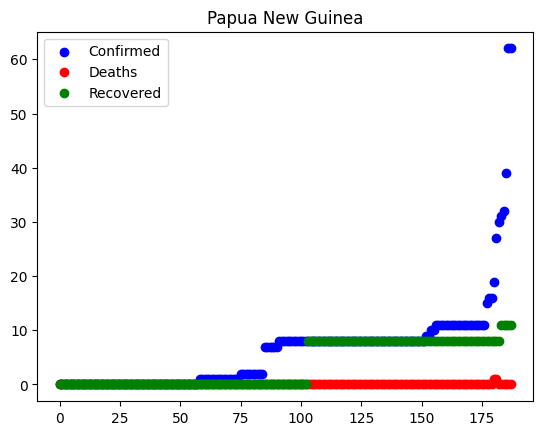

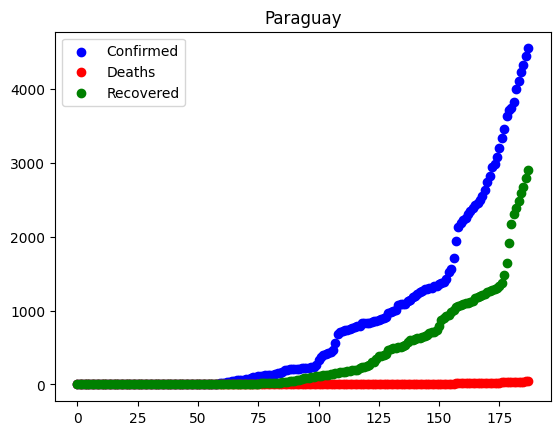

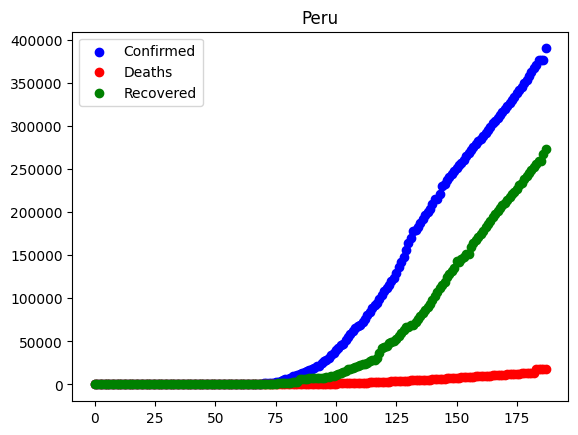

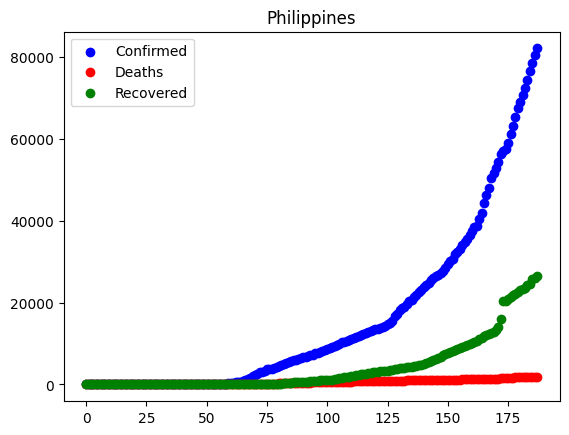

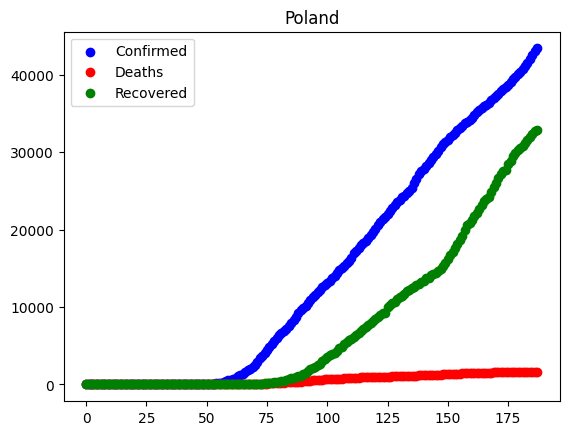

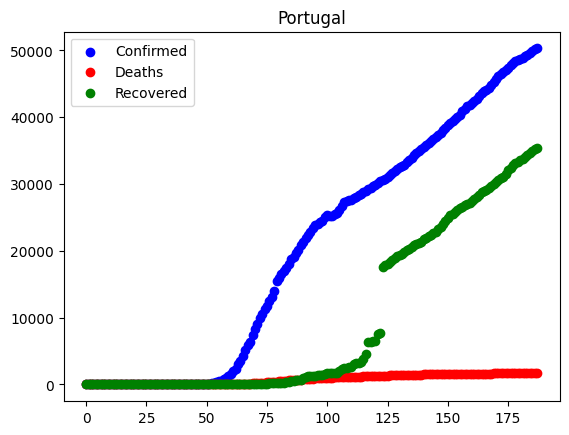

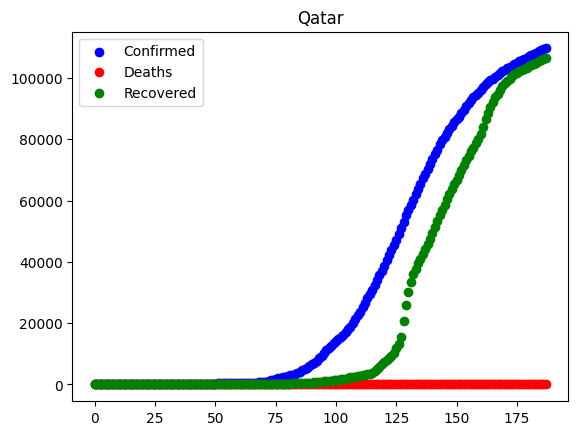

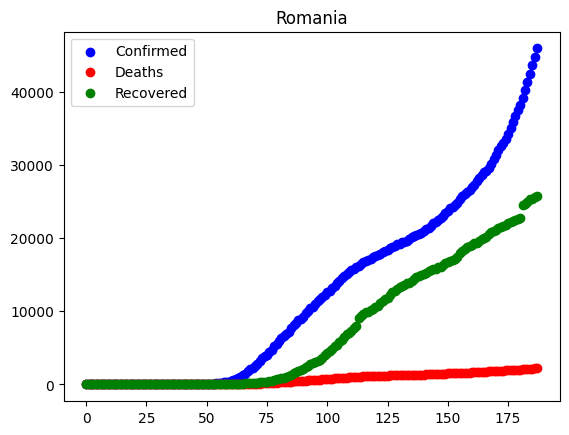

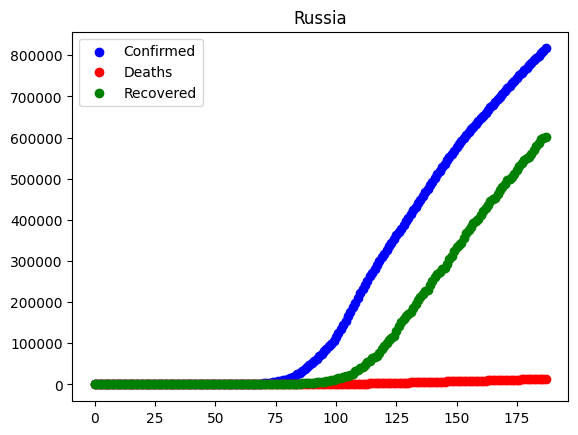

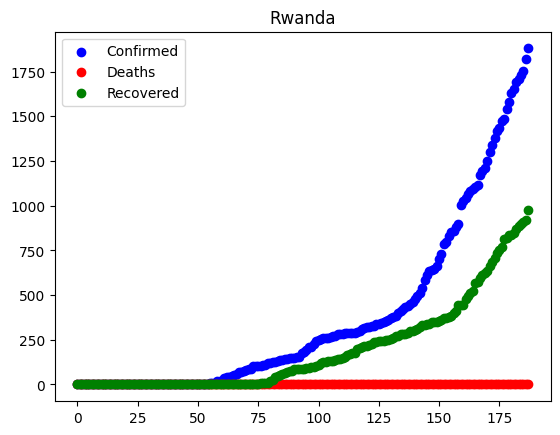

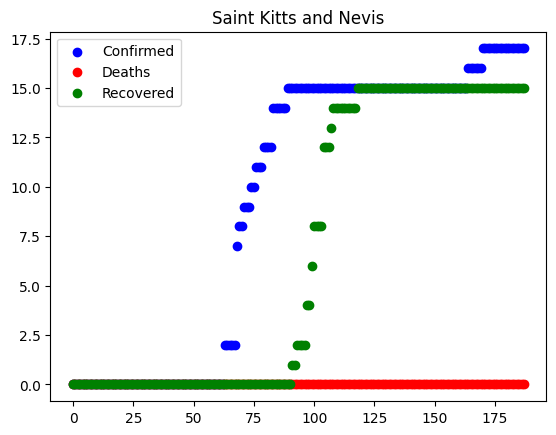

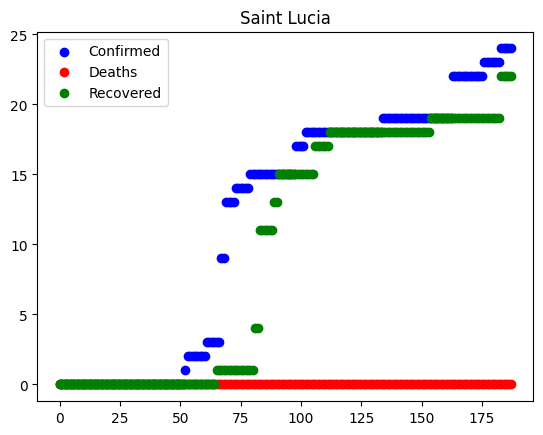

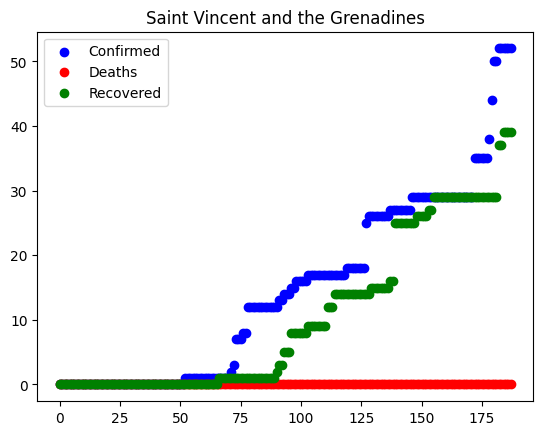

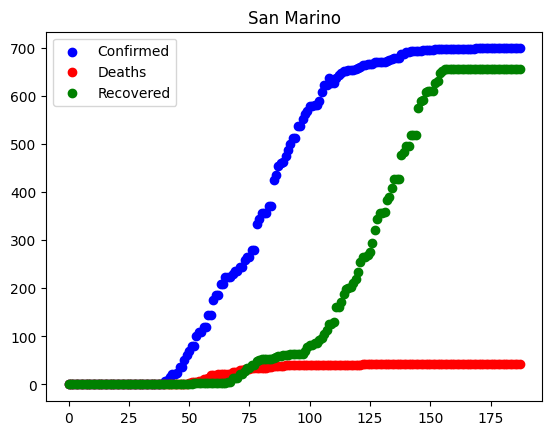

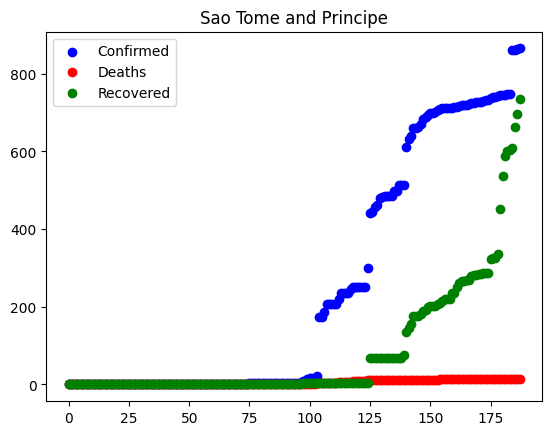

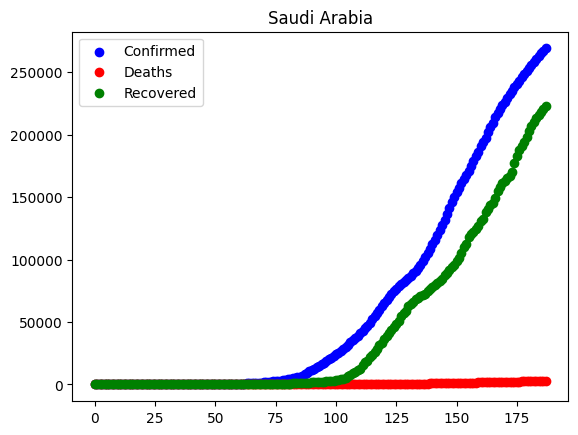

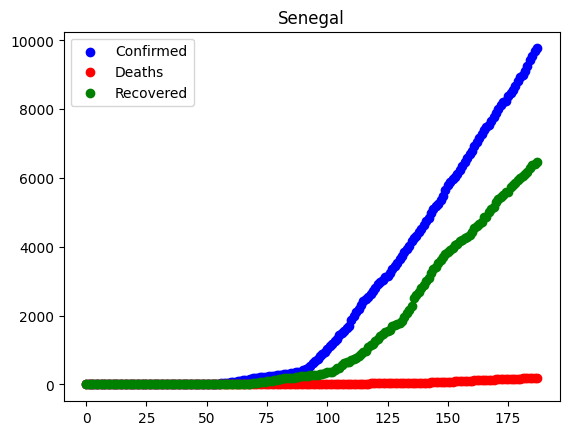

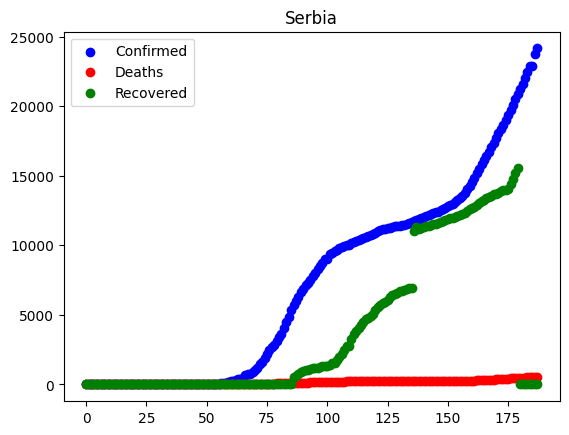

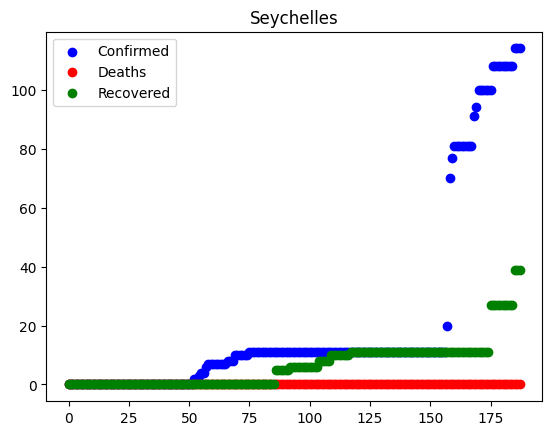

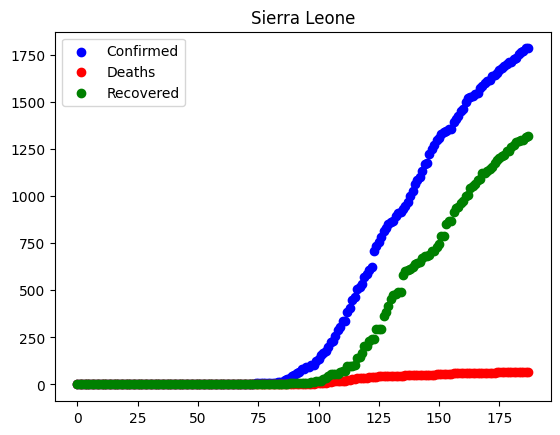

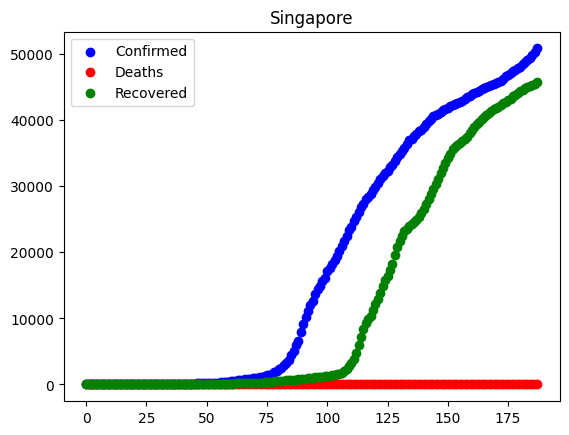

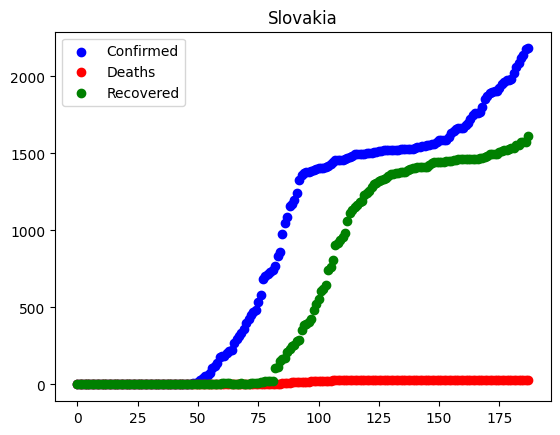

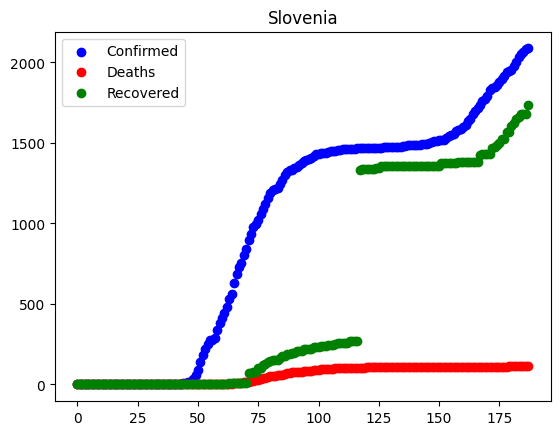

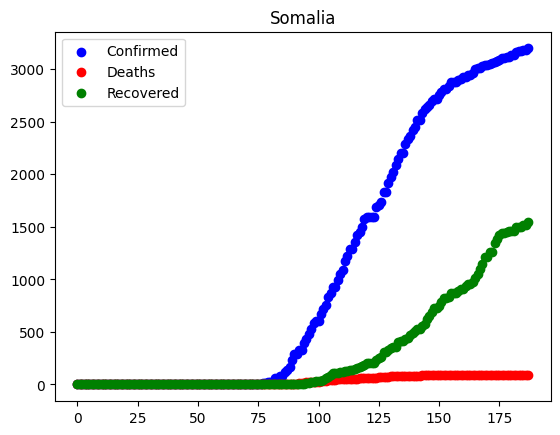

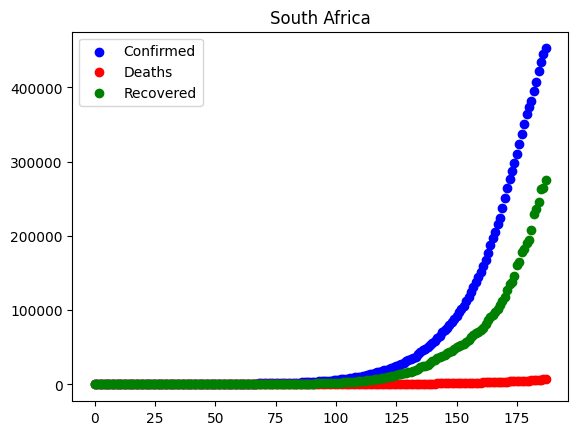

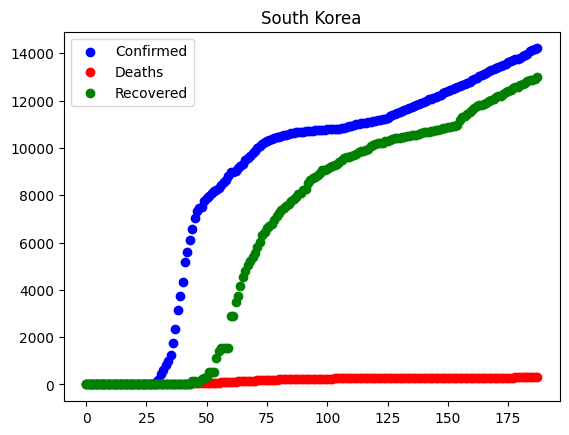

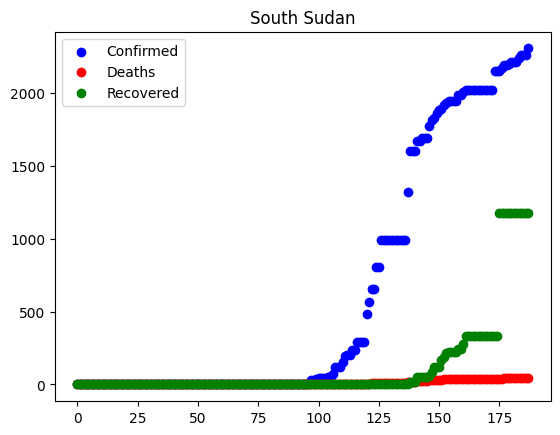

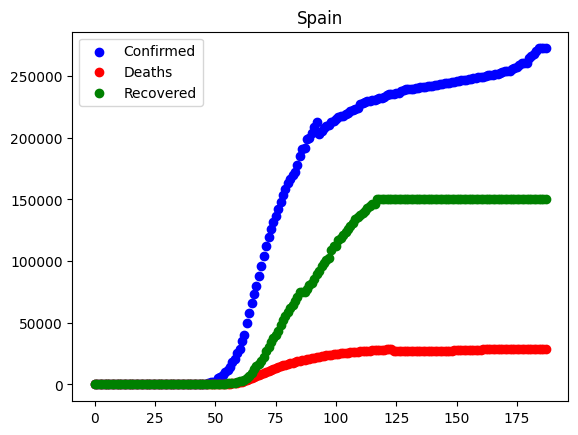

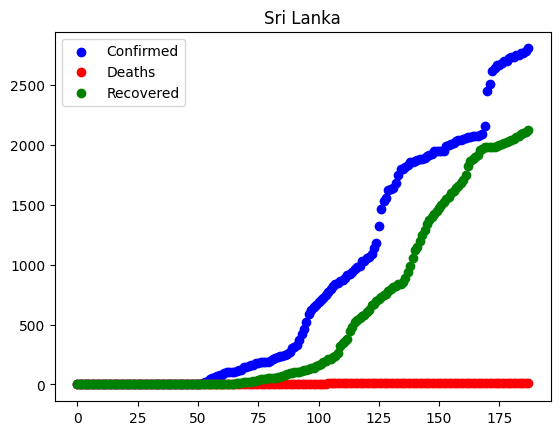

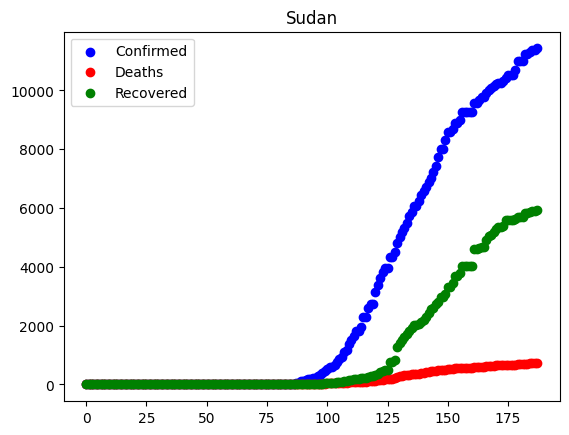

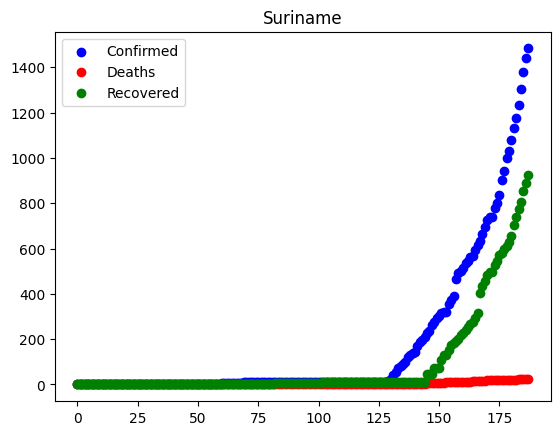

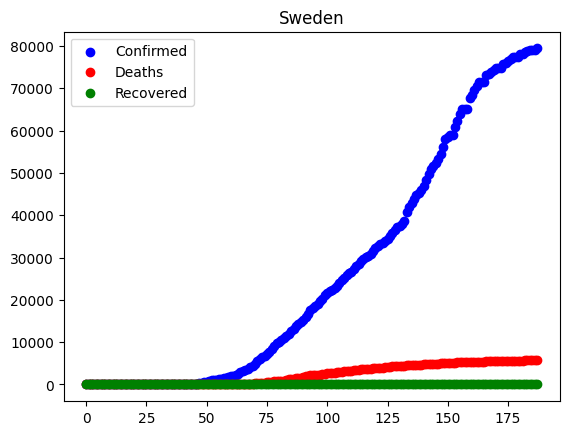

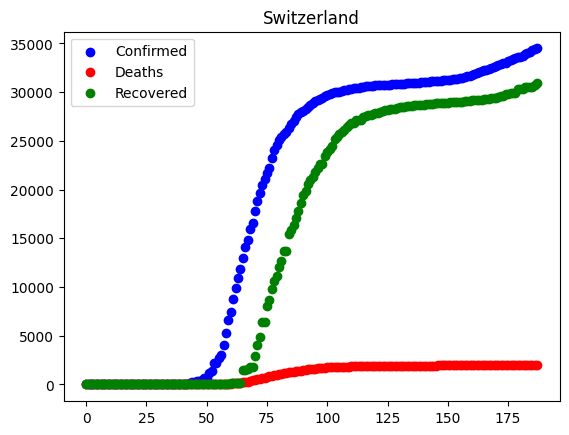

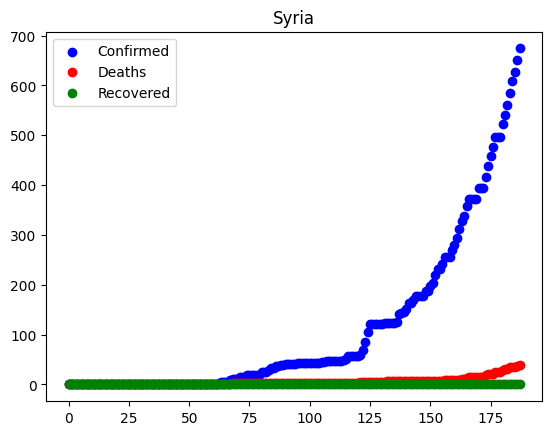

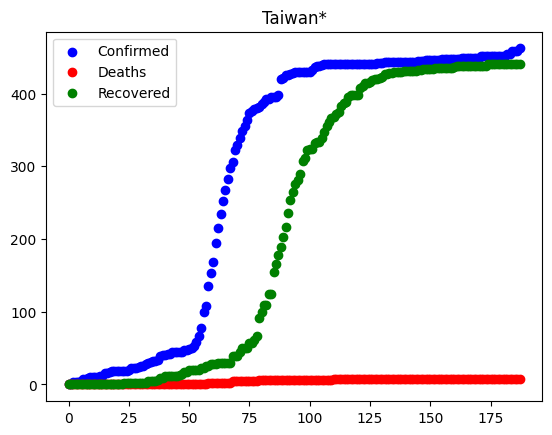

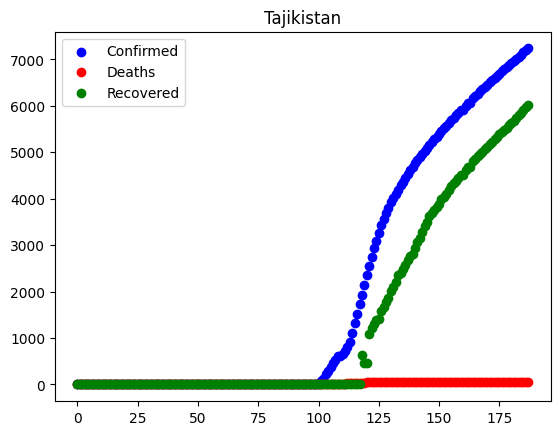

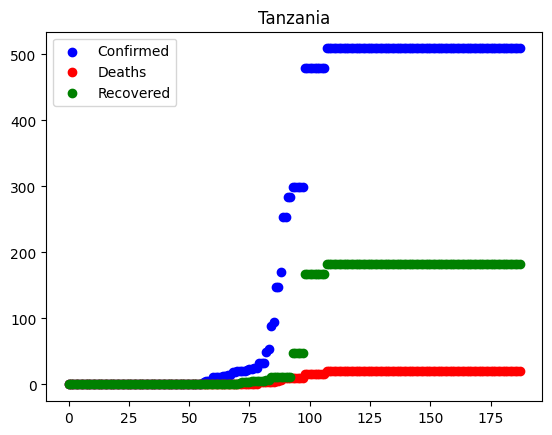

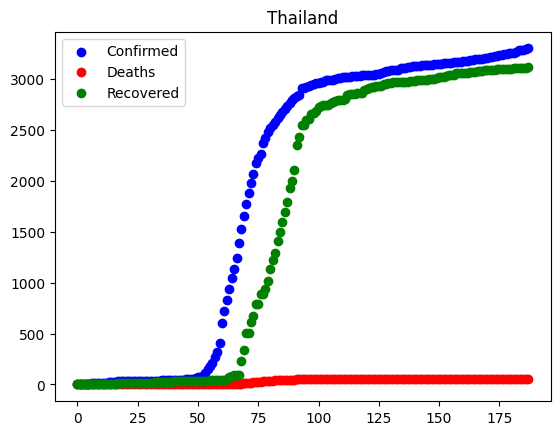

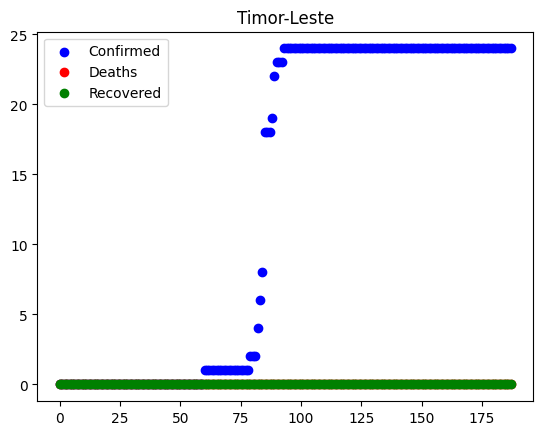

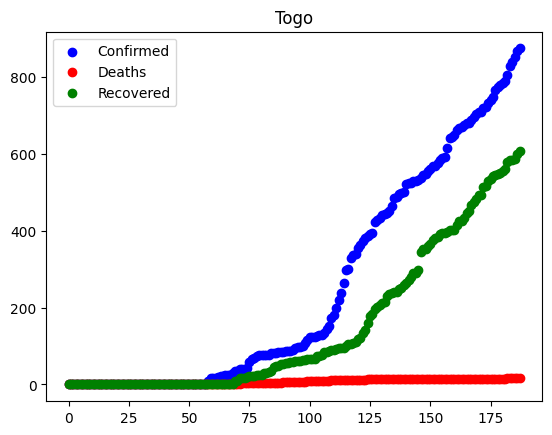

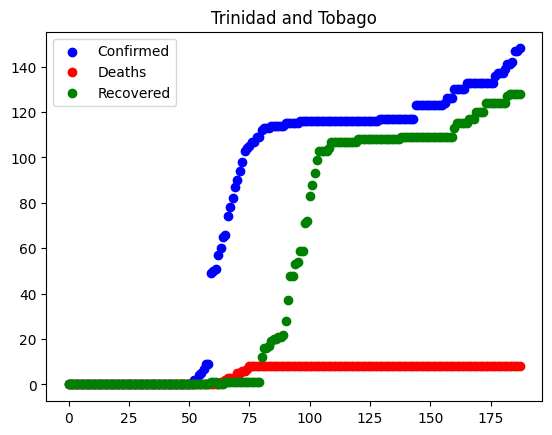

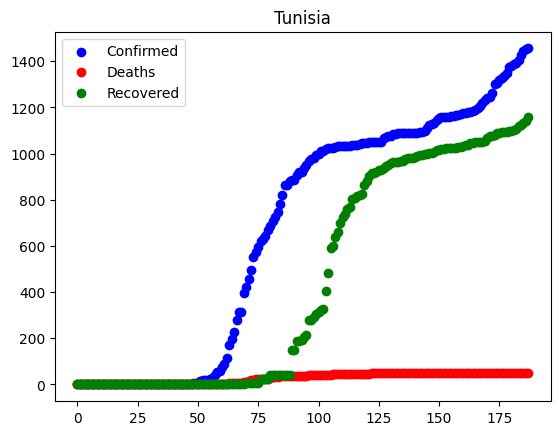

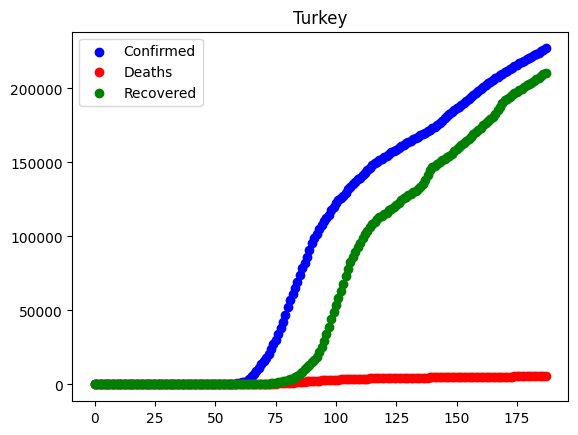

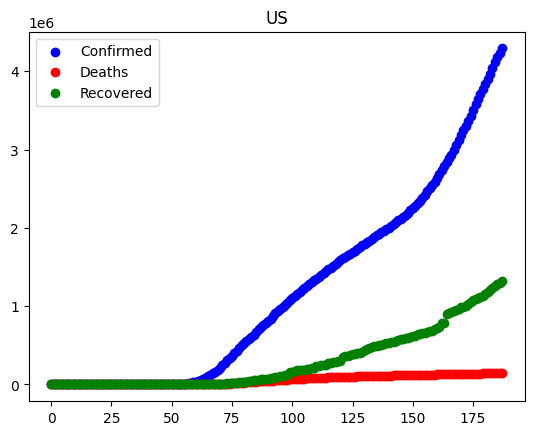

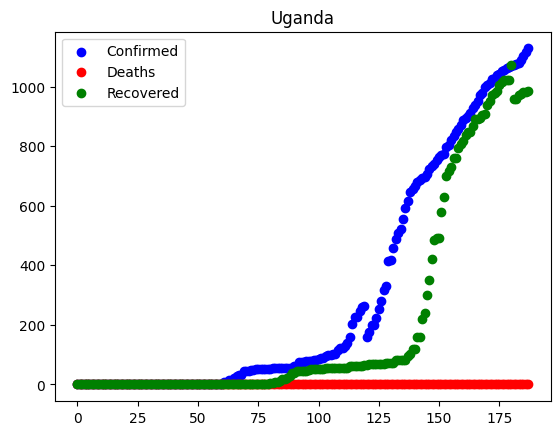

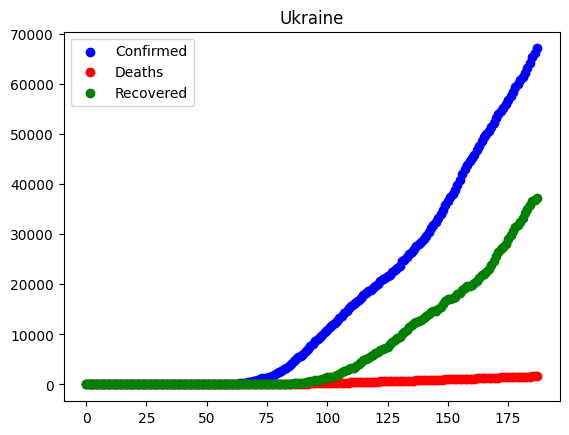

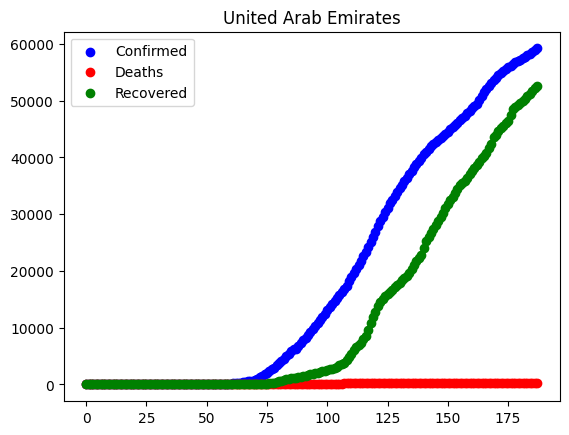

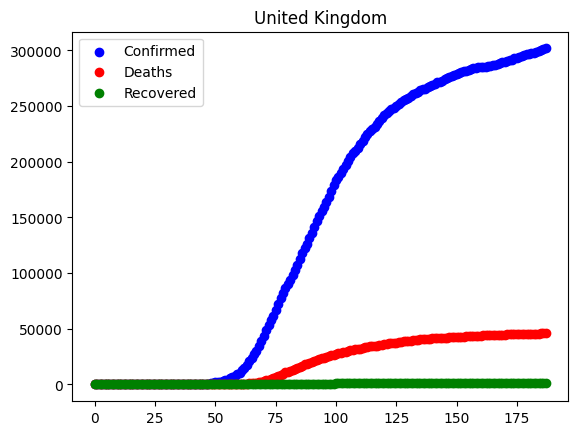

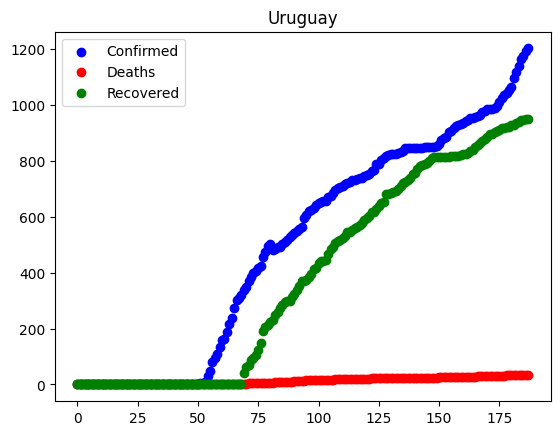

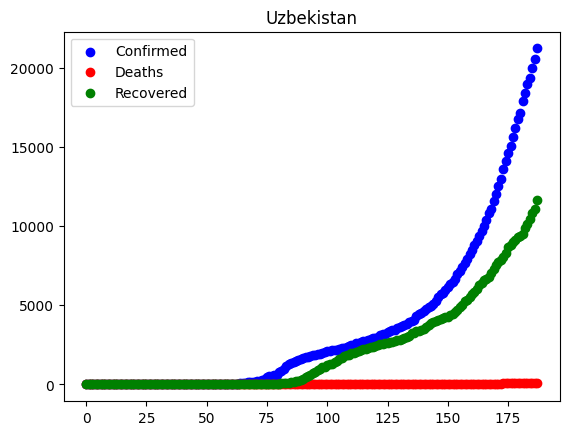

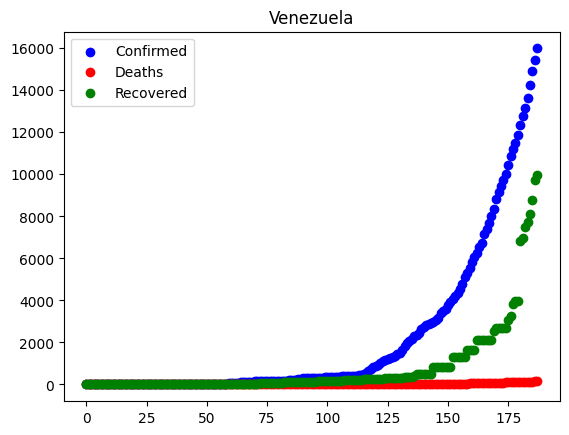

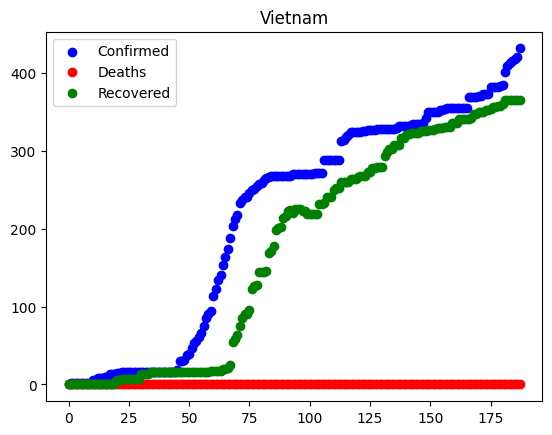

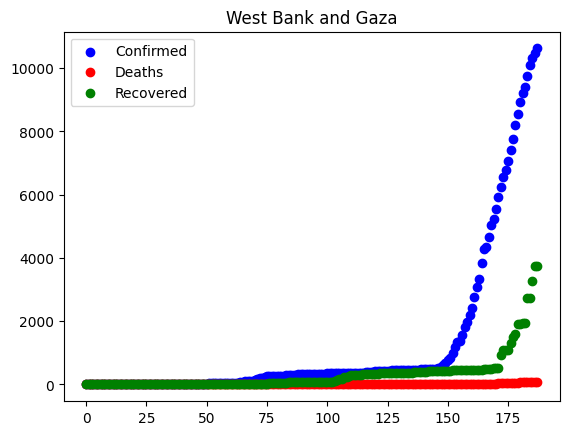

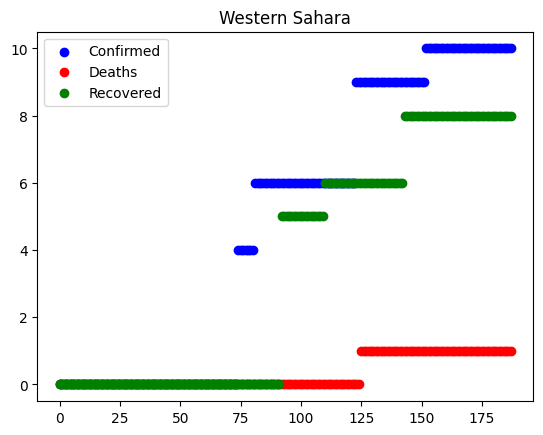

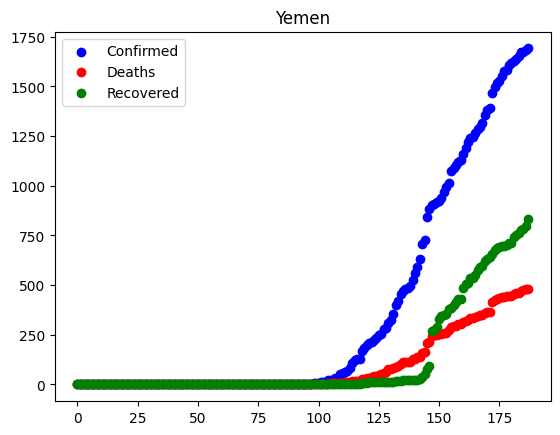

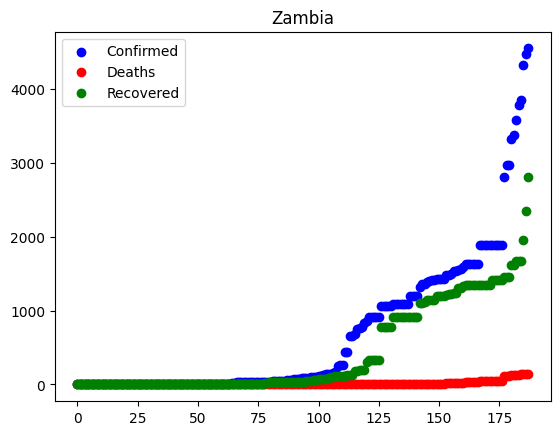

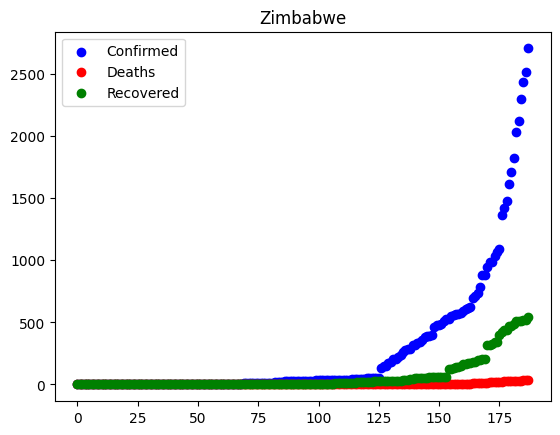

In [ ]:
for country_idx in range(len(countries)):
  country = df3[df3['Country']==countries[country_idx]].reset_index()
  plt.scatter(np.arange(0,len(country)),country['Confirmed'],color='blue',label='Confirmed')
  plt.scatter(np.arange(0,len(country)),country['Deaths'],color='red',label='Deaths')
  plt.scatter(np.arange(0,len(country)),country['Recovered'],color='green',label='Recovered')
  plt.title(countries[country_idx])
  plt.legend()
  plt.show()